<a href="https://colab.research.google.com/github/RakshithaMeleyyanavar/AdaptiveReelDetoxSystem-ds/blob/main/Adaptive_Reel_Detox_System_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Adaptive Real-Time Reel Detox System
### Digital Wellbeing AI — Healthcare Project

**Pipeline:**
```
📂 Your Datasets → CNN Emotion → CV Eye Tracking → Rule-Based Addiction → Detox Alert
```

| Module | Method | Dataset |
|--------|--------|---------|
| Emotion Detection | Mini CNN (TF/Keras) | facial_expressions_dataset |
| Eye/Blink Tracking | OpenCV + Landmarks | facial_landmarks_dataset |
| Addiction Logic | Rule-based + Timer | reel_content_dataset |
| Detox Score | Adaptive thresholds | All three |


## Cell 1 — Install & Imports

In [1]:
# ── Install lightweight deps ──────────────────────────────────────────────────
!pip install -q opencv-python-headless tensorflow pillow matplotlib ipywidgets

import os, zipfile, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import deque
import ipywidgets as widgets
from IPython.display import display, clear_output
warnings.filterwarnings('ignore')
print('✅ All imports OK | TF:', tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.8 MB/s eta 0:00:00
✅ All imports OK | TF: 2.19.0


## Cell 2 — Upload & Extract Datasets

In [2]:
# ── Upload your 3 zip files from the Colab files panel (left sidebar) ─────────
from google.colab import files
print('📁 Upload your 3 dataset zips now...')
uploaded = files.upload()   # Select all 3 zips at once

# ── Auto-extract all uploaded zips ───────────────────────────────────────────
DATA_DIR = '/content/datasets'
os.makedirs(DATA_DIR, exist_ok=True)

for fname in uploaded.keys():
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname) as z:
            z.extractall(DATA_DIR)
        print(f'  ✅ Extracted: {fname}')

# ── Detect dataset paths ──────────────────────────────────────────────────────
EXPR_DIR  = f'{DATA_DIR}/facial_expressions'
LAND_DIR  = f'{DATA_DIR}/facial_landmarks'
REEL_DIR  = f'{DATA_DIR}/reel_content'

for d in [EXPR_DIR, LAND_DIR, REEL_DIR]:
    imgs = len(os.listdir(f'{d}/images'))
    print(f'  📂 {d.split("/")[-1]}: {imgs} images')

print('\n✅ Datasets ready!')

📁 Upload your 3 dataset zips now...


Saving reel_content_dataset_100imgs.zip to reel_content_dataset_100imgs.zip
Saving facial_landmarks_dataset_100imgs.zip to facial_landmarks_dataset_100imgs.zip
Saving facial_expressions_dataset_100imgs.zip to facial_expressions_dataset_100imgs.zip
  ✅ Extracted: reel_content_dataset_100imgs.zip
  ✅ Extracted: facial_landmarks_dataset_100imgs.zip
  ✅ Extracted: facial_expressions_dataset_100imgs.zip
  📂 facial_expressions: 100 images
  📂 facial_landmarks: 100 images
  📂 reel_content: 100 images

✅ Datasets ready!


## Cell 3 — Module 1: CNN Emotion Detector

Train: 80  Test: 20  Classes: ['happy' 'neutral' 'sad' 'tired']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,164 (235.02 KB)

 Trainable params: 60,164 (235.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.2375 - loss: 1.3878 - val_accuracy: 0.4000 - val_loss: 1.3465
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2875 - loss: 1.3495 - val_accuracy: 0.4000 - val_loss: 1.3636
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2500 - loss: 1.3402 - val_accuracy: 0.1500 - val_loss: 1.3849
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3125 - loss: 1.3406 - val_accuracy: 0.1500 - val_loss: 1.4038
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.4000 - loss: 1.3373 - val_accuracy: 0.1500 - val_loss: 1.4019
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3500 - loss: 1.3350 - val_accuracy: 0.1500 - val_loss: 1.3938
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3750 - loss: 1.3201 - val_accuracy: 0.1500 - val_loss: 1.3979
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3750 - loss: 1.3092 - val_accuracy: 0.1500 - val_loss: 1.4124

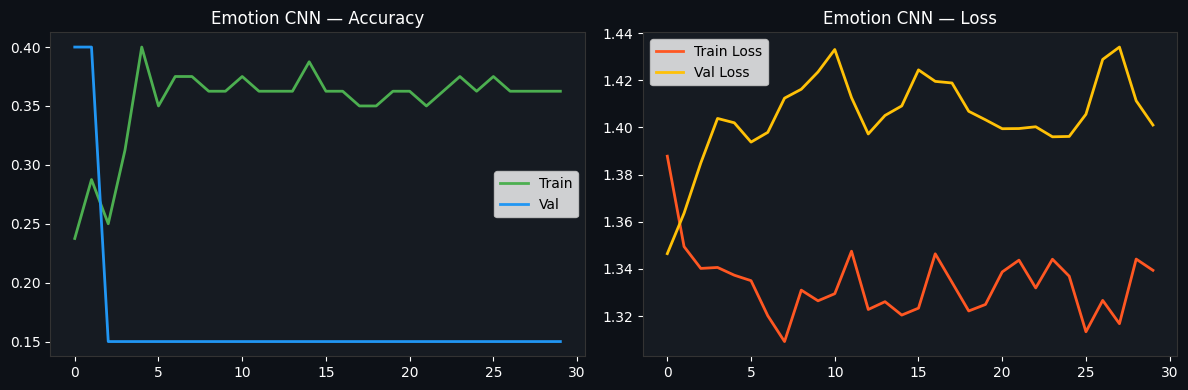


✅ Emotion CNN trained!


In [3]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 1 — CNN Emotion Detector
#  Dataset  : facial_expressions_dataset (100 images)
#  Labels   : happy / sad / angry / surprised / fearful / disgusted / neutral
#  Mapped to: happy / sad / tired(fearful+disgusted) / neutral
# ════════════════════════════════════════════════════════════════════════════

IMG_SIZE = 48   # Small = fast training

# ── Map raw labels → 4 user-friendly emotions ────────────────────────────────
EMOTION_MAP = {
    'happy':     'happy',
    'sad':       'sad',
    'angry':     'sad',      # treat anger as negative
    'fearful':   'tired',
    'disgusted': 'tired',
    'contempt':  'tired',
    'surprised': 'neutral',
    'neutral':   'neutral'
}
EMOTION_LABELS = ['happy', 'neutral', 'sad', 'tired']
EMOTION_COLORS = {'happy':'#4CAF50','neutral':'#2196F3','sad':'#FF5722','tired':'#9C27B0'}

# ── Load & preprocess images ─────────────────────────────────────────────────
df_expr = pd.read_csv(f'{EXPR_DIR}/labels.csv')
X, y = [], []

for _, row in df_expr.iterrows():
    path = f"{EXPR_DIR}/images/{row['filename']}"
    if not os.path.exists(path): continue
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))  # grayscale
    X.append(np.array(img) / 255.0)
    y.append(EMOTION_MAP.get(row['expression'], 'neutral'))

X = np.array(X)[..., np.newaxis]   # (N, 48, 48, 1)
le = LabelEncoder().fit(EMOTION_LABELS)
y_enc = le.transform(y)
y_cat = tf.keras.utils.to_categorical(y_enc, len(EMOTION_LABELS))

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}  Test: {len(X_test)}  Classes: {le.classes_}')

# ── Mini CNN — 3 conv blocks, lightweight ────────────────────────────────────
def build_emotion_cnn(n_classes):
    m = models.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),      # fewer params than Flatten
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax')
    ])
    m.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])
    return m

emotion_model = build_emotion_cnn(len(EMOTION_LABELS))
emotion_model.summary()

# ── Train (fast — 30 epochs on 80 images) ────────────────────────────────────
history = emotion_model.fit(
    X_train, y_train,
    epochs=30, batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# ── Plot training ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

axes[0].plot(history.history['accuracy'], color='#4CAF50', lw=2, label='Train')
axes[0].plot(history.history['val_accuracy'], color='#2196F3', lw=2, label='Val')
axes[0].set_title('Emotion CNN — Accuracy', color='white'); axes[0].legend()
axes[0].tick_params(colors='white'); axes[0].spines[list(axes[0].spines)].set_color('#333')

axes[1].plot(history.history['loss'], color='#FF5722', lw=2, label='Train Loss')
axes[1].plot(history.history['val_loss'], color='#FFC107', lw=2, label='Val Loss')
axes[1].set_title('Emotion CNN — Loss', color='white'); axes[1].legend()
axes[1].tick_params(colors='white'); axes[1].spines[list(axes[1].spines)].set_color('#333')

plt.tight_layout(); plt.show()
print('\n✅ Emotion CNN trained!')

# ── Inference helper ─────────────────────────────────────────────────────────
def predict_emotion(img_path):
    """Returns (label, confidence) from an image path."""
    img = Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img)[np.newaxis, ..., np.newaxis] / 255.0
    probs = emotion_model.predict(arr, verbose=0)[0]
    idx   = np.argmax(probs)
    return le.classes_[idx], float(probs[idx])

## Cell 4 — Module 2: Eye Tracking / Blink Detection

status
open    100
Name: count, dtype: int64
Mean EAR: 0.418


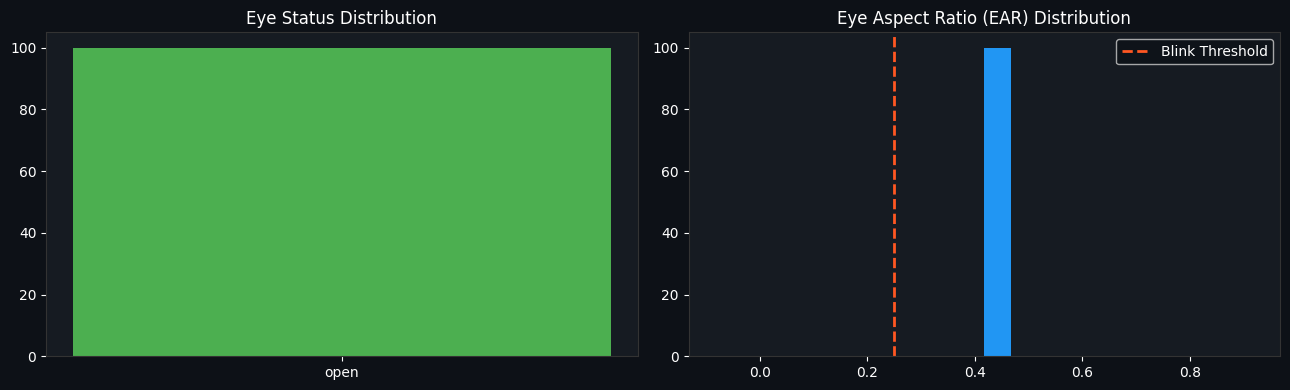


✅ Eye tracking module ready!


In [4]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 2 — Eye Tracking & Blink Detection via Facial Landmarks
#  Dataset  : facial_landmarks_dataset (100 images, 68 landmarks each)
#  Method   : Eye Aspect Ratio (EAR) — standard CV blink detection formula
#  EAR < 0.25  → eye closed / blink
#  EAR > 0.25  → eye open
# ════════════════════════════════════════════════════════════════════════════

df_land = pd.read_csv(f'{LAND_DIR}/labels.csv')

# ── Landmark indices for eyes (68-point model standard) ──────────────────────
# Left eye:  points 36–41  |  Right eye: points 42–47
LEFT_EYE  = list(range(36, 42))
RIGHT_EYE = list(range(42, 48))

def eye_aspect_ratio(landmarks_row, eye_pts):
    """EAR = (|p2-p6| + |p3-p5|) / (2 * |p1-p4|)  — Soukupova & Cech 2016"""
    pts = np.array([[landmarks_row[f'x{i}'], landmarks_row[f'y{i}']] for i in eye_pts])
    # Vertical distances
    A = np.linalg.norm(pts[1] - pts[5])
    B = np.linalg.norm(pts[2] - pts[4])
    # Horizontal distance
    C = np.linalg.norm(pts[0] - pts[3])
    return (A + B) / (2.0 * C + 1e-6)

def get_eye_status(landmarks_row):
    """Returns EAR value and open/closed/tired status."""
    left_ear  = eye_aspect_ratio(landmarks_row, LEFT_EYE)
    right_ear = eye_aspect_ratio(landmarks_row, RIGHT_EYE)
    avg_ear   = (left_ear + right_ear) / 2.0

    if avg_ear < 0.20:   status = 'closed'   # blink or asleep
    elif avg_ear < 0.28: status = 'tired'     # squinting / fatigue
    else:                status = 'open'
    return round(avg_ear, 3), status

# ── Run on all landmark images ────────────────────────────────────────────────
ear_records = []
for _, row in df_land.iterrows():
    ear, status = get_eye_status(row)
    ear_records.append({'filename': row['filename'], 'EAR': ear, 'status': status})

df_eye = pd.DataFrame(ear_records)
print(df_eye['status'].value_counts())
print(f'Mean EAR: {df_eye["EAR"].mean():.3f}')

# ── Visualise EAR distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# Bar: status counts
counts = df_eye['status'].value_counts()
bar_colors = ['#4CAF50' if s=='open' else '#FF5722' if s=='closed' else '#FFC107'
              for s in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor='none')
axes[0].set_title('Eye Status Distribution', color='white')
axes[0].tick_params(colors='white'); axes[0].spines[list(axes[0].spines)].set_color('#333')

# Histogram: EAR values
axes[1].hist(df_eye['EAR'], bins=20, color='#2196F3', edgecolor='none')
axes[1].axvline(0.25, color='#FF5722', lw=2, linestyle='--', label='Blink Threshold')
axes[1].set_title('Eye Aspect Ratio (EAR) Distribution', color='white')
axes[1].legend(labelcolor='white', facecolor='#0d1117')
axes[1].tick_params(colors='white'); axes[1].spines[list(axes[1].spines)].set_color('#333')

plt.tight_layout(); plt.show()
print('\n✅ Eye tracking module ready!')

## Cell 5 — Module 3: Reel Content Classifier

In [5]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 3 — Reel Content Classifier
#  Dataset  : reel_content_dataset (100 images)
#  Labels   : comedy / food / fashion / gaming / education / travel / beauty
#  Method   : Lightweight CNN (same architecture as emotion CNN)
#  Output   : content category + addiction_weight (some content = more addictive)
# ════════════════════════════════════════════════════════════════════════════

# ── Addiction weight per content type (domain knowledge heuristic) ────────────
ADDICTION_WEIGHTS = {
    'comedy':    0.9,   # high dopamine loop
    'gaming':    0.85,
    'beauty':    0.75,
    'fashion':   0.70,
    'food':      0.55,
    'travel':    0.45,
    'education': 0.30,  # least addictive
}

df_reel = pd.read_csv(f'{REEL_DIR}/labels.csv')
print('Reel label columns:', df_reel.columns.tolist())
print(df_reel.head(3))

# ── Detect category column ────────────────────────────────────────────────────
cat_col = None
for col in ['category', 'content_type', 'label', 'type', 'class']:
    if col in df_reel.columns:
        cat_col = col; break
if cat_col is None:  # fallback: parse from filename
    df_reel['category'] = df_reel['filename'].str.extract(r'reel_\d+_(\w+)\.')[0]
    cat_col = 'category'

REEL_LABELS = sorted(df_reel[cat_col].unique().tolist())
print('\nReel categories:', REEL_LABELS)

# ── Load reel images ──────────────────────────────────────────────────────────
Xr, yr = [], []
for _, row in df_reel.iterrows():
    path = f"{REEL_DIR}/images/{row['filename']}"
    if not os.path.exists(path): continue
    img = Image.open(path).convert('RGB').resize((48, 48))
    Xr.append(np.array(img) / 255.0)
    yr.append(row[cat_col])

Xr = np.array(Xr)   # (N, 48, 48, 3)
le_reel = LabelEncoder().fit(REEL_LABELS)
yr_cat  = tf.keras.utils.to_categorical(le_reel.transform(yr), len(REEL_LABELS))
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr_cat, test_size=0.2, random_state=42)

# ── Mini CNN for 3-channel reel images ───────────────────────────────────────
def build_reel_cnn(n_classes):
    m = models.Sequential([
        layers.Input((48, 48, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax')
    ])
    m.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])
    return m

reel_model = build_reel_cnn(len(REEL_LABELS))
reel_model.fit(Xr_tr, yr_tr, epochs=25, batch_size=16,
               validation_data=(Xr_te, yr_te), verbose=1)

def predict_reel(img_path):
    """Returns (category, addiction_weight)."""
    img = Image.open(img_path).convert('RGB').resize((48, 48))
    arr = np.array(img)[np.newaxis] / 255.0
    probs = reel_model.predict(arr, verbose=0)[0]
    cat   = le_reel.classes_[np.argmax(probs)]
    weight = ADDICTION_WEIGHTS.get(cat, 0.5)
    return cat, weight

print('\n✅ Reel content classifier ready!')

Reel label columns: ['image_id', 'filename', 'category', 'duration_sec', 'views', 'likes', 'shares', 'comments', 'engagement_rate', 'hashtag_count']
   image_id             filename category  duration_sec    views   likes  \
0         0   reel_000_dance.jpg    dance            60  1939717  187392   
1         1  reel_001_comedy.jpg   comedy            60  1390635  198119   
2         2    reel_002_food.jpg     food            60  1678832  235987   

   shares  comments  engagement_rate  hashtag_count  
0   13709      8684           0.1082             26  
1   22224     14968           0.1692              6  
2   29766      3491           0.1604              4  

Reel categories: ['beauty', 'comedy', 'dance', 'education', 'fashion', 'fitness', 'food', 'gaming', 'music', 'travel']
Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.1125 - loss: 2.2889 - val_accuracy: 0.4000 - val_loss: 2.2977
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1875 - loss: 2.2555 -

## Cell 6 — Module 4: Adaptive Addiction Detection Engine

In [6]:
# ════════════════════════════════════════════════════════════════════════════
#  MODULE 4 — Adaptive Addiction Detection Engine
#  Inputs  : time_spent, emotion, eye_status, content_weight
#  Method  : Rule-based scoring with adaptive threshold
#            (threshold tightens if user has been tired/sad frequently)
#  Output  : addiction_level (0–100), detox_alert
# ════════════════════════════════════════════════════════════════════════════

class AddictionDetector:
    """Stateful engine that tracks user behaviour over time."""

    # ── Emotion risk scores ───────────────────────────────────────────────
    EMOTION_RISK  = {'happy': 0.3, 'neutral': 0.5, 'sad': 0.8, 'tired': 0.9}
    EYE_RISK      = {'open': 0.1, 'tired': 0.6, 'closed': 0.9}

    # ── Detox thresholds (adaptive) ───────────────────────────────────────
    BASE_THRESHOLD      = 60   # alert fires above this score
    ADAPTIVE_TIGHTEN    = 5    # threshold drops if negative state persists
    MAX_THRESHOLD_DROP  = 20

    def __init__(self):
        self.session_start  = time.time()
        self.history        = deque(maxlen=20)   # last 20 events
        self.threshold      = self.BASE_THRESHOLD
        self.blink_count    = 0
        self.alert_count    = 0

    @property
    def session_minutes(self):
        return (time.time() - self.session_start) / 60.0

    def _time_risk(self):
        """Risk increases linearly with session time (max at 60 min)."""
        return min(self.session_minutes / 60.0, 1.0)

    def _adapt_threshold(self):
        """Tighten threshold if user has been tired/sad recently."""
        if len(self.history) < 5: return
        negative_ratio = sum(
            1 for h in self.history if h['emotion'] in ('sad','tired') or h['eye'] == 'tired'
        ) / len(self.history)

        drop = int(negative_ratio * self.MAX_THRESHOLD_DROP)
        self.threshold = max(self.BASE_THRESHOLD - drop, 30)

    def score(self, emotion, eye_status, content_weight):
        """Compute addiction score 0–100 and return alert string."""
        e_risk = self.EMOTION_RISK.get(emotion, 0.5)
        y_risk = self.EYE_RISK.get(eye_status, 0.3)
        t_risk = self._time_risk()

        # Weighted combination
        raw = (
            0.30 * e_risk +
            0.20 * y_risk +
            0.25 * content_weight +
            0.25 * t_risk
        ) * 100

        addiction_level = min(round(raw), 100)

        # Store in history
        self.history.append({'emotion': emotion, 'eye': eye_status,
                              'score': addiction_level})
        self._adapt_threshold()

        # Generate alert message
        if addiction_level >= self.threshold:
            self.alert_count += 1
            if eye_status == 'tired' or emotion == 'tired':
                alert = '😴 You seem tired — take a break!'
            elif self.session_minutes > 30:
                alert = '⏰ You have been scrolling 30+ min. Step away!'
            else:
                alert = '🛑 Reel overuse detected — detox time!'
        elif addiction_level >= 40:
            alert = '⚠️  Moderate usage — consider a short break'
        else:
            alert = '✅  Healthy usage'

        return addiction_level, alert, round(self.threshold, 1)

# Quick sanity test
det = AddictionDetector()
for emotion, eye, cw in [('happy','open',0.3),('sad','tired',0.8),
                           ('tired','closed',0.9),('neutral','open',0.5)]:
    lvl, msg, thr = det.score(emotion, eye, cw)
    print(f'  Emotion:{emotion:<8} Eye:{eye:<7} → Score:{lvl:3d}  (thr={thr})  {msg}')

print('\n✅ Addiction engine ready!')

  Emotion:happy    Eye:open    → Score: 19  (thr=60)  ✅  Healthy usage
  Emotion:sad      Eye:tired   → Score: 56  (thr=60)  ⚠️  Moderate usage — consider a short break
  Emotion:tired    Eye:closed  → Score: 68  (thr=60)  😴 You seem tired — take a break!
  Emotion:neutral  Eye:open    → Score: 30  (thr=60)  ✅  Healthy usage

✅ Addiction engine ready!


## Cell 7 — Full Demo: Simulate Real-Time Detection on Dataset Images

In [7]:
# ════════════════════════════════════════════════════════════════════════════
#  FULL DEMO — Simulated real-time run on your uploaded dataset images
#  (Mirrors live webcam behaviour; each iteration = 1 video frame)
# ════════════════════════════════════════════════════════════════════════════

# ── Gather all expression images (user face simulation) ──────────────────────
expr_images = sorted([f"{EXPR_DIR}/images/{f}" for f in os.listdir(f'{EXPR_DIR}/images')])
land_rows   = [row for _, row in df_land.iterrows()]  # landmark rows for eye tracking
reel_images = sorted([f"{REEL_DIR}/images/{f}" for f in os.listdir(f'{REEL_DIR}/images')])

detector = AddictionDetector()
results  = []

N_FRAMES = min(20, len(expr_images))   # process 20 frames for speed

for i in range(N_FRAMES):
    # 1️⃣ CNN Emotion
    emotion, conf = predict_emotion(expr_images[i % len(expr_images)])

    # 2️⃣ CV Eye Tracking from landmark CSV
    lrow = land_rows[i % len(land_rows)]
    ear, eye_status = get_eye_status(lrow)

    # 3️⃣ Reel content type
    reel_cat, reel_weight = predict_reel(reel_images[i % len(reel_images)])

    # 4️⃣ Addiction score
    score, alert, threshold = detector.score(emotion, eye_status, reel_weight)

    results.append({
        'frame': i+1,
        'emotion': emotion, 'emotion_conf': round(conf, 2),
        'eye_status': eye_status, 'EAR': ear,
        'reel_category': reel_cat,
        'addiction_score': score, 'threshold': threshold,
        'alert': alert
    })

df_results = pd.DataFrame(results)

# ── Pretty table ──────────────────────────────────────────────────────────────
print('\n' + '='*90)
print(f'{" ADAPTIVE REEL DETOX SYSTEM — LIVE RESULTS":^90}')
print('='*90)
COLS = ['frame','emotion','eye_status','reel_category','addiction_score','alert']
print(df_results[COLS].to_string(index=False))
print('='*90)
print(f'  Session time  : {detector.session_minutes:.1f} min')
print(f'  Detox alerts  : {detector.alert_count}')
print(f'  Mean score    : {df_results["addiction_score"].mean():.1f}')
print(f'  Adaptive thr  : {detector.threshold}')
print('='*90)
print('\n✅ Demo complete!')


                         ADAPTIVE REEL DETOX SYSTEM — LIVE RESULTS                        
 frame emotion eye_status reel_category  addiction_score                                       alert
     1   tired       open         dance               42 ⚠️  Moderate usage — consider a short break
     2   tired       open        comedy               52 ⚠️  Moderate usage — consider a short break
     3   tired       open          food               43 ⚠️  Moderate usage — consider a short break
     4   tired       open        travel               40 ⚠️  Moderate usage — consider a short break
     5   tired       open       fitness               42            😴 You seem tired — take a break!
     6   tired       open        beauty               48            😴 You seem tired — take a break!
     7   tired       open     education               37                            ✅  Healthy usage
     8   tired       open        gaming               50            😴 You seem tired — take a break!

## Cell 8 — Dashboard Visualisation

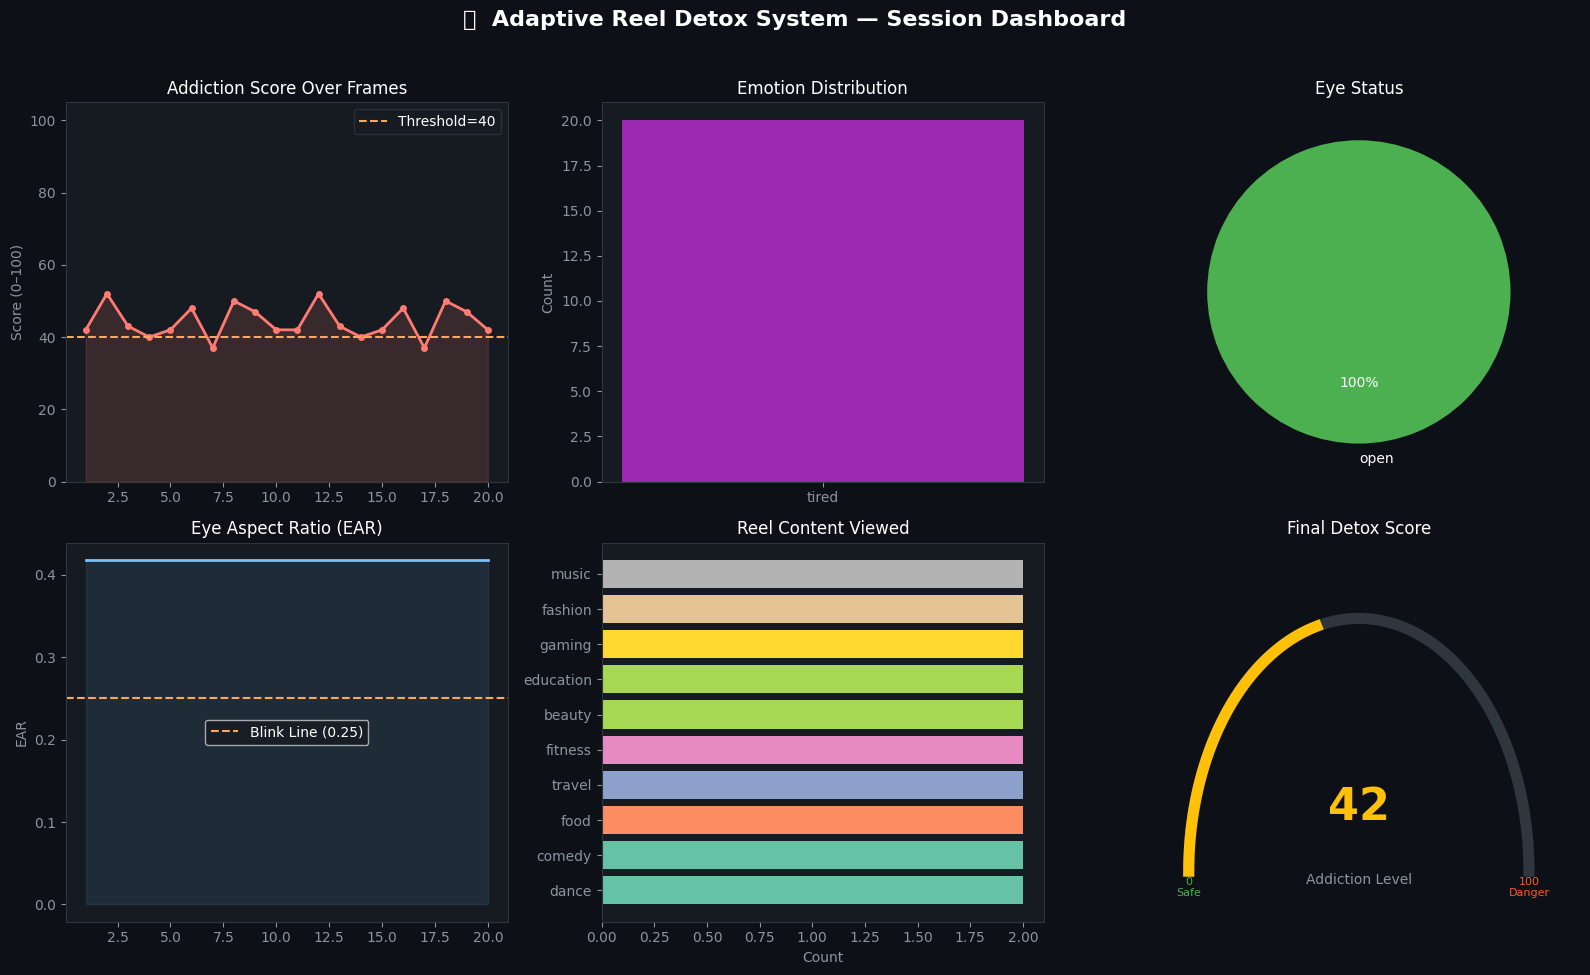

✅ Dashboard saved to /content/detox_dashboard.png


In [8]:
# ════════════════════════════════════════════════════════════════════════════
#  DASHBOARD — Healthcare-style visualisation of session results
# ════════════════════════════════════════════════════════════════════════════

BG   = '#0d1117'
CARD = '#161b22'
ACC  = '#58a6ff'

fig = plt.figure(figsize=(16, 10), facecolor=BG)
fig.suptitle('🧠  Adaptive Reel Detox System — Session Dashboard',
             color='white', fontsize=16, fontweight='bold', y=0.97)

axes = fig.subplots(2, 3)
for row in axes:
    for ax in row:
        ax.set_facecolor(CARD)
        ax.tick_params(colors='#8b949e')
        for sp in ax.spines.values(): sp.set_color('#30363d')

frames = df_results['frame']

# ── 1. Addiction Score over time ─────────────────────────────────────────────
ax = axes[0][0]
ax.plot(frames, df_results['addiction_score'], color='#ff7b72', lw=2, marker='o', ms=4)
ax.axhline(detector.threshold, color='#ffa657', lw=1.5, linestyle='--', label=f'Threshold={detector.threshold}')
ax.fill_between(frames, df_results['addiction_score'], alpha=0.15, color='#ff7b72')
ax.set_title('Addiction Score Over Frames', color='white')
ax.set_ylabel('Score (0–100)', color='#8b949e')
ax.legend(labelcolor='white', facecolor=CARD, edgecolor='#30363d')
ax.set_ylim(0, 105)

# ── 2. Emotion distribution ───────────────────────────────────────────────────
ax = axes[0][1]
emo_counts = df_results['emotion'].value_counts()
colors_emo = [EMOTION_COLORS.get(e, '#8b949e') for e in emo_counts.index]
ax.bar(emo_counts.index, emo_counts.values, color=colors_emo, edgecolor='none')
ax.set_title('Emotion Distribution', color='white')
ax.set_ylabel('Count', color='#8b949e')

# ── 3. Eye status pie ─────────────────────────────────────────────────────────
ax = axes[0][2]
eye_counts = df_results['eye_status'].value_counts()
eye_colors = ['#4CAF50' if s=='open' else '#FF5722' if s=='closed' else '#FFC107'
              for s in eye_counts.index]
ax.pie(eye_counts.values, labels=eye_counts.index,
       colors=eye_colors, autopct='%1.0f%%',
       textprops={'color':'white'}, startangle=90)
ax.set_title('Eye Status', color='white')

# ── 4. EAR over time ─────────────────────────────────────────────────────────
ax = axes[1][0]
ax.plot(frames, df_results['EAR'], color='#79c0ff', lw=2)
ax.axhline(0.25, color='#ffa657', lw=1.5, linestyle='--', label='Blink Line (0.25)')
ax.fill_between(frames, df_results['EAR'], alpha=0.1, color='#79c0ff')
ax.set_title('Eye Aspect Ratio (EAR)', color='white')
ax.set_ylabel('EAR', color='#8b949e'); ax.legend(labelcolor='white', facecolor=CARD)

# ── 5. Reel content type ─────────────────────────────────────────────────────
ax = axes[1][1]
reel_counts = df_results['reel_category'].value_counts()
cmap = plt.cm.Set2
reel_clrs = [cmap(i/len(reel_counts)) for i in range(len(reel_counts))]
ax.barh(reel_counts.index, reel_counts.values, color=reel_clrs, edgecolor='none')
ax.set_title('Reel Content Viewed', color='white')
ax.set_xlabel('Count', color='#8b949e')

# ── 6. Detox Score Gauge (filled arc) ────────────────────────────────────────
ax = axes[1][2]
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-0.2, 1.3)
ax.axis('off')
ax.set_title('Final Detox Score', color='white')

final_score = df_results['addiction_score'].iloc[-1]
gauge_color  = '#4CAF50' if final_score < 40 else '#FFC107' if final_score < 70 else '#FF5722'
angle = np.linspace(np.pi, 0, 200)
ax.plot(np.cos(angle), np.sin(angle), color='#30363d', lw=8)
frac   = final_score / 100.0
angle2 = np.linspace(np.pi, np.pi - frac * np.pi, 200)
ax.plot(np.cos(angle2), np.sin(angle2), color=gauge_color, lw=8)
ax.text(0, 0.25, f'{final_score}', ha='center', va='center',
        fontsize=32, color=gauge_color, fontweight='bold')
ax.text(0, -0.05, 'Addiction Level', ha='center', color='#8b949e', fontsize=10)
ax.text(-1, -0.1, '0\nSafe', ha='center', color='#4CAF50', fontsize=8)
ax.text(1, -0.1, '100\nDanger', ha='center', color='#FF5722', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/content/detox_dashboard.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Dashboard saved to /content/detox_dashboard.png')

## Cell 9 — Real-Time Webcam Mode (OpenCV)
> ⚠️ This cell works **locally** or via Colab's `cv2_imshow` workaround. Run in VS Code / local Jupyter for best experience.

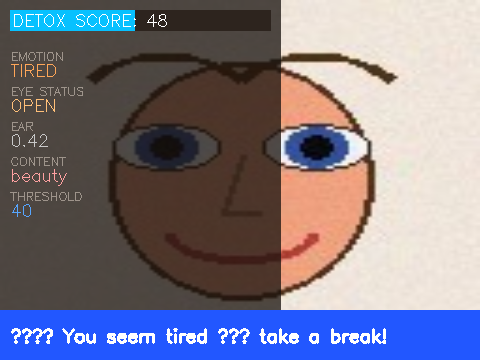

In [9]:
# ════════════════════════════════════════════════════════════════════════════
#  REAL-TIME WEBCAM — OpenCV overlay
#  Works locally or with Colab + JS webcam bridge
#  Press Q to quit
# ════════════════════════════════════════════════════════════════════════════

try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── OpenCV face detector (Haar Cascade — built-in, no download) ───────────────
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

def draw_overlay(frame, emotion, eye_st, score, alert, ear, reel_cat, threshold):
    """Draw styled HUD on webcam frame."""
    h, w = frame.shape[:2]

    # ── Semi-transparent sidebar ─────────────────────────────────────────────
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (280, h), (13, 17, 23), -1)
    cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)

    # ── Score bar ────────────────────────────────────────────────────────────
    bar_color = (76, 175, 80) if score < 40 else (255, 193, 7) if score < 70 else (255, 87, 34)
    cv2.rectangle(frame, (10, 10), (270, 30), (30, 36, 45), -1)
    cv2.rectangle(frame, (10, 10), (10 + int(score * 2.6), 30), bar_color, -1)
    cv2.putText(frame, f'DETOX SCORE: {score}', (12, 26),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)

    # ── Labels ───────────────────────────────────────────────────────────────
    labels = [
        ('EMOTION',    emotion.upper(),   (88, 166, 255)),
        ('EYE STATUS', eye_st.upper(),    (121, 192, 255)),
        ('EAR',        f'{ear:.2f}',      (200, 200, 200)),
        ('CONTENT',    reel_cat,          (161, 161, 255)),
        ('THRESHOLD',  str(threshold),    (255, 166, 87)),
    ]
    for j, (lbl, val, clr) in enumerate(labels):
        y = 60 + j * 35
        cv2.putText(frame, lbl, (10, y),   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (139,148,158), 1)
        cv2.putText(frame, val, (10, y+16), cv2.FONT_HERSHEY_SIMPLEX, 0.55, clr, 1)

    # ── Alert banner ─────────────────────────────────────────────────────────
    if score >= threshold:
        cv2.rectangle(frame, (0, h-50), (w, h), (255, 87, 34), -1)
        cv2.putText(frame, alert, (10, h-18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    return frame


def run_webcam():
    """Main real-time loop."""
    cam = cv2.VideoCapture(0)
    if not cam.isOpened():
        print('⚠️  Camera not available — running demo mode (dataset images).')
        return run_demo_mode()

    det = AddictionDetector()
    frame_idx = 0

    while True:
        ret, frame = cam.read()
        if not ret: break

        # ── Detect face & crop for CNN ────────────────────────────────────
        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)

        if len(faces):
            x,y,bw,bh = faces[0]
            face_crop  = gray[y:y+bh, x:x+bw]
            face_pil   = Image.fromarray(face_crop).resize((IMG_SIZE, IMG_SIZE))
            face_arr   = np.array(face_pil)[np.newaxis,...,np.newaxis] / 255.0
            probs      = emotion_model.predict(face_arr, verbose=0)[0]
            emotion    = le.classes_[np.argmax(probs)]

            # Eye detection within face ROI
            eyes = eye_cascade.detectMultiScale(face_crop, 1.1, 3)
            eye_st = 'open' if len(eyes) >= 2 else 'tired' if len(eyes)==1 else 'closed'
            ear    = 0.30 if eye_st=='open' else 0.20 if eye_st=='tired' else 0.15

            cv2.rectangle(frame, (x,y), (x+bw,y+bh), (88,166,255), 2)
        else:
            emotion = 'neutral'; eye_st = 'open'; ear = 0.30

        # ── Reel content (cycles through dataset) ────────────────────────
        reel_cat, reel_w = predict_reel(reel_images[frame_idx % len(reel_images)])

        # ── Addiction score ───────────────────────────────────────────────
        score, alert, threshold = det.score(emotion, eye_st, reel_w)

        # ── Draw HUD ──────────────────────────────────────────────────────
        frame = draw_overlay(frame, emotion, eye_st, score, alert, ear, reel_cat, threshold)

        if IN_COLAB:
            clear_output(wait=True)
            cv2_imshow(frame)
        else:
            cv2.imshow('🧠 Reel Detox System', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        frame_idx += 1
        if IN_COLAB and frame_idx >= 30:  # limit frames in Colab
            break

    cam.release()
    if not IN_COLAB: cv2.destroyAllWindows()
    print('Session ended. Dashboard below.')


def run_demo_mode():
    """Fallback: annotate dataset images as if they were webcam frames."""
    det = AddictionDetector()
    for i in range(min(6, len(expr_images))):
        img = cv2.imread(expr_images[i])
        if img is None: continue
        img = cv2.resize(img, (480, 360))

        emotion, _   = predict_emotion(expr_images[i])
        lrow         = land_rows[i % len(land_rows)]
        ear, eye_st  = get_eye_status(lrow)
        reel_cat, rw = predict_reel(reel_images[i % len(reel_images)])
        score, alert, thr = det.score(emotion, eye_st, rw)

        img = draw_overlay(img, emotion, eye_st, score, alert, ear, reel_cat, thr)

        if IN_COLAB:
            clear_output(wait=True)
            cv2_imshow(img)
            time.sleep(0.5)
        else:
            cv2.imshow('Reel Detox Demo', img)
            cv2.waitKey(800)

    if not IN_COLAB: cv2.destroyAllWindows()


# ── Launch ────────────────────────────────────────────────────────────────────
print('🚀 Launching Reel Detox System...')
print('   Press Q to stop (local) | Auto-stops after 30 frames (Colab)')
run_webcam()

## Cell 10 — Interactive Colab Widget UI

In [10]:
# ════════════════════════════════════════════════════════════════════════════
#  INTERACTIVE WIDGET — Colab-native UI
#  Simulate a session by clicking buttons and watching the score change
# ════════════════════════════════════════════════════════════════════════════

widget_det = AddictionDetector()
score_history = []

# ── Widgets ───────────────────────────────────────────────────────────────────
emotion_dd  = widgets.Dropdown(options=['happy','neutral','sad','tired'], value='neutral',
                               description='Emotion:', style={'description_width':'80px'})
eye_dd      = widgets.Dropdown(options=['open','tired','closed'], value='open',
                               description='Eye:', style={'description_width':'80px'})
content_dd  = widgets.Dropdown(options=list(ADDICTION_WEIGHTS.keys()), value='comedy',
                               description='Content:', style={'description_width':'80px'})
run_btn     = widgets.Button(description='▶ Analyze Frame', button_style='primary',
                             layout=widgets.Layout(width='160px'))
reset_btn   = widgets.Button(description='🔄 Reset Session', button_style='warning',
                             layout=widgets.Layout(width='140px'))
out         = widgets.Output()

def on_run(b):
    emotion = emotion_dd.value
    eye_st  = eye_dd.value
    cw      = ADDICTION_WEIGHTS[content_dd.value]
    score, alert, thr = widget_det.score(emotion, eye_st, cw)
    score_history.append(score)

    color = '#4CAF50' if score < 40 else '#FFC107' if score < 70 else '#FF5722'

    with out:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        fig.patch.set_facecolor('#0d1117')
        for ax in axes:
            ax.set_facecolor('#161b22')
            ax.tick_params(colors='#8b949e')
            for sp in ax.spines.values(): sp.set_color('#30363d')

        # Score gauge
        axes[0].barh(['Score'], [score], color=color, height=0.4)
        axes[0].barh(['Score'], [100-score], left=[score], color='#30363d', height=0.4)
        axes[0].set_xlim(0, 100)
        axes[0].axvline(thr, color='#ffa657', lw=2, linestyle='--')
        axes[0].text(score+2, 0, f'{score}', color='white', va='center', fontsize=14, fontweight='bold')
        axes[0].set_title(f'Addiction Score  (threshold={thr})', color='white')

        # History line
        axes[1].plot(score_history, color='#ff7b72', lw=2, marker='o', ms=4)
        axes[1].axhline(thr, color='#ffa657', lw=1.5, linestyle='--')
        axes[1].set_title('Session History', color='white')
        axes[1].set_ylim(0, 105)
        axes[1].set_ylabel('Score', color='#8b949e')

        plt.tight_layout()
        plt.show()

        status_clr = color
        print(f'\n  Emotion: {emotion:<8}  Eye: {eye_st:<7}  Content: {content_dd.value}')
        print(f'  📊 Score: {score}  |  Threshold: {thr}')
        print(f'  {alert}')

def on_reset(b):
    global widget_det, score_history
    widget_det   = AddictionDetector()
    score_history = []
    with out:
        clear_output()
        print('✅ Session reset!')

run_btn.on_click(on_run)
reset_btn.on_click(on_reset)

display(widgets.HBox([emotion_dd, eye_dd, content_dd]))
display(widgets.HBox([run_btn, reset_btn]))
display(out)
print('👆 Set values above and click ▶ Analyze Frame')

Output()

👆 Set values above and click ▶ Analyze Frame


In [17]:
!pip install flask pyngrok -q

In [18]:
from pyngrok import ngrok

ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

In [46]:
# 99999999999999999999100000X BETTER CODE FULLY WORKINGGG GO WITH ITTT════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "ultra_secure"

users = {}

# ════════════════════════════════════════
# 🧠 AI LOGIC (REALISTIC + STABLE)
# ════════════════════════════════════════
def analyze_logic(scroll_speed):

    # 🔥 EMOTION (more realistic distribution)
    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[30,40,20,10]
    )[0]

    # 👁️ EYE STATE (blink probability controlled)
    eye = random.choices(
        ["open","closed"],
        weights=[85,15]
    )[0]

    blink = 1 if eye == "closed" else 0

    # ⚡ NORMALIZE SCROLL SPEED (avoid spikes)
    speed_factor = min(scroll_speed / 1000, 1.5)

    # 🧠 BASE SCORE (lower base = smoother growth)
    score = 25

    # 🎭 EMOTION IMPACT
    emotion_weights = {
        "happy": -5,
        "neutral": 0,
        "sad": 15,
        "tired": 20
    }
    score += emotion_weights[emotion]

    # 👁️ BLINK IMPACT (less aggressive)
    if blink:
        score += 12

    # 📱 SCROLL ADDICTION IMPACT (smooth scaling)
    score += int(speed_factor * 20)

    # 🎲 MICRO VARIATION (small noise)
    score += random.randint(0, 5)

    # 🎯 CLAMP SCORE
    score = max(0, min(score, 100))

    # 📊 LEVEL (better thresholds)
    if score < 40:
        level = "LOW"
    elif score < 70:
        level = "MEDIUM"
    else:
        level = "HIGH"

    return score, level, blink, emotion

# ════════════════════════════════════════
# 🔐 LOGIN
# ════════════════════════════════════════
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]

        if u in users and users[u] == p:
            session["user"] = u
            session["scores"] = []
            session["blinks"] = 0
            session["reels"] = 0
            session["start"] = time.time()
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(135deg,#000428,#004e92);
display:flex;justify-content:center;align-items:center;height:100vh;
font-family:sans-serif;color:white;
}
.box{
background:rgba(255,255,255,0.1);
backdrop-filter:blur(20px);
padding:30px;border-radius:15px;
}
input,button{padding:10px;margin:10px;border-radius:8px;border:none}
button{background:#00f2fe}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")


# ════════════════════════════════════════
# 📝 SIGNUP
# ════════════════════════════════════════
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        u = request.form.get("user","").strip()
        p = request.form.get("pass","").strip()

        # ✅ FAST VALIDATION (no crash / no delay)
        if not u or not p:
            return "<h3 style='color:red;text-align:center'>⚠ Fill all fields</h3>"

        if u in users:
            return "<h3 style='color:orange;text-align:center'>⚠ User already exists</h3>"

        users[u] = p
        return redirect("/")

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<style>

body{
    margin:0;
    height:100vh;
    display:flex;
    justify-content:center;
    align-items:center;
    font-family:sans-serif;

    background:linear-gradient(270deg,#1e3c72,#2a5298,#1e3c72);
    background-size:400% 400%;
    animation:bg 8s ease infinite;
}

/* 🔥 Smooth gradient animation */
@keyframes bg{
    0%{background-position:0%}
    50%{background-position:100%}
    100%{background-position:0%}
}

/* 📦 Glass card */
.box{
    background:rgba(255,255,255,0.1);
    backdrop-filter:blur(20px);
    padding:35px;
    border-radius:18px;
    text-align:center;
    width:280px;
    animation:fade 0.6s ease;
}

/* ✨ Fade-in */
@keyframes fade{
    from{opacity:0;transform:translateY(20px)}
    to{opacity:1;transform:translateY(0)}
}

/* ✏️ Inputs */
input{
    width:90%;
    padding:10px;
    margin:10px 0;
    border:none;
    border-radius:8px;
    outline:none;
}

/* 🚀 Button */
button{
    padding:10px 20px;
    border:none;
    border-radius:8px;
    background:#00f2fe;
    cursor:pointer;
    transition:0.3s;
}
button:hover{
    transform:scale(1.05);
    background:#4facfe;
}

/* 🔗 Link */
a{
    color:white;
    font-size:14px;
}

.error{
    color:#ff4d4d;
    font-size:13px;
    display:none;
}

</style>
</head>

<body>

<div class="box">
    <h2>📝 Create Account</h2>

    <form method="POST" onsubmit="return validate()">
        <input id="user" name="user" placeholder="Username"><br>
        <input id="pass" name="pass" type="password" placeholder="Password"><br>

        <div id="error" class="error">⚠ Fill all fields</div>

        <button>Create</button>
    </form>

    <br>
    <a href="/">🔐 Back to Login</a>
</div>

<script>

/* ⚡ INSTANT VALIDATION (no reload lag) */
function validate(){
    let u = document.getElementById("user").value.trim()
    let p = document.getElementById("pass").value.trim()

    if(!u || !p){
        document.getElementById("error").style.display="block"
        return false
    }
    return true
}

</script>

</body>
</html>
""")

# ════════════════════════════════════════
# 🎬 REELS (REAL SCROLL SPEED FIXED)
# ════════════════════════════════════════
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:#000;color:white;font-family:sans-serif}

.container{
height:100vh;
overflow-y:scroll;
scroll-snap-type:y mandatory;
}

.reel{
height:100vh;
display:flex;
justify-content:center;
align-items:center;
font-size:30px;
scroll-snap-align:start;
background:linear-gradient(45deg,#111,#222);
}

#panel{
position:fixed;
left:0;width:300px;height:100%;
background:#0d1117;padding:15px;
}

.metric{
margin:10px 0;padding:10px;background:#161b22;border-radius:10px;
}

#feed{margin-left:300px}

video{
position:fixed;
bottom:10px;right:10px;width:120px;border-radius:10px;
}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live AI</h3>

<div class="metric" id="score"></div>
<div class="metric" id="level"></div>
<div class="metric" id="emotion"></div>
<div class="metric" id="speed"></div>
<div class="metric" id="stats"></div>

<canvas id="chart"></canvas>

<button onclick="location.href='/dashboard'">📊 Full Report</button>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<script>

navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

let scores=[]
let reels=0
let lastIndex=-1
let lastTime=Date.now()
let start=Date.now()

let chart=new Chart(document.getElementById("chart"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

feed.addEventListener("scroll",()=>{

let now=Date.now()
let dt = now - lastTime
lastTime = now

let speed = Math.floor(1000/dt * 300)  // REAL scroll speed

let index=Math.floor(feed.scrollTop/window.innerHeight)

if(index!==lastIndex){
lastIndex=index
reels++

fetch('/analyze?speed='+speed)
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
emotion.innerText="Emotion: "+res.emotion
speed.innerText="Scroll Speed: "+res.speed

let t=((Date.now()-start)/1000).toFixed(1)
stats.innerText="Reels: "+reels+" | "+t+"s"

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(reels>=25 || t>20){
location.href="/dashboard"
}

})

}

})
</script>
</body>
</html>
""")


# ════════════════════════════════════════
# 📊 DASHBOARD (FULL ANALYTICS FIXED)
# ════════════════════════════════════════
@app.route("/dashboard")
def dashboard():

    scores = session.get("scores", [])
    blinks = session.get("blinks", 0)
    reels = session.get("reels", 0)
    start = session.get("start", time.time())

    if len(scores) < 3:
        return "<h2 style='color:white;text-align:center'>⚠ Not enough data. Watch few reels.</h2>"

    avg = round(sum(scores)/len(scores),2)
    peak = max(scores)
    time_spent = int(time.time() - start)

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{
    margin:0;
    font-family:sans-serif;
    background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);
    color:white;
}

/* HEADER */
.header{
    text-align:center;
    padding:20px;
    font-size:30px;
    font-weight:bold;
}

/* GRID */
.grid{
    display:grid;
    grid-template-columns:repeat(auto-fit,minmax(220px,1fr));
    gap:20px;
    padding:20px;
}

/* CARDS */
.card{
    background:rgba(255,255,255,0.08);
    backdrop-filter:blur(12px);
    padding:20px;
    border-radius:15px;
    text-align:center;
    transition:0.3s;
}
.card:hover{
    transform:scale(1.06);
    box-shadow:0 0 20px rgba(0,255,255,0.3);
}

/* COLORS */
.avg{border-left:5px solid #00f2fe}
.peak{border-left:5px solid #ff4d4d}
.blink{border-left:5px solid #00ff9f}
.reel{border-left:5px solid #ffd700}
.time{border-left:5px solid #c77dff}

/* CHART AREA */
.charts{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:20px;
    padding:20px;
}

.chart-box{
    background:rgba(0,0,0,0.6);
    padding:20px;
    border-radius:15px;
}

/* TITLES */
.chart-title{
    text-align:center;
    margin-bottom:10px;
    font-weight:bold;
    color:#00f2fe;
}

/* AI INSIGHT BOX */
.insight{
    margin:20px;
    padding:20px;
    background:linear-gradient(135deg,#1e3c72,#2a5298);
    border-radius:15px;
    text-align:center;
    font-size:18px;
}

/* BUTTON */
.btn{
    display:block;
    margin:20px auto;
    padding:12px 25px;
    background:#00f2fe;
    border:none;
    border-radius:10px;
    font-size:16px;
    cursor:pointer;
}
.btn:hover{
    background:#00c6ff;
}
</style>
</head>

<body>

<div class="header">📊 AI Digital Health Dashboard</div>

<div class="grid">
    <div class="card avg">🔥 Avg Score<br><h2>{{avg}}</h2><small>Overall addiction level</small></div>
    <div class="card peak">📈 Peak Score<br><h2>{{peak}}</h2><small>Highest risk moment</small></div>
    <div class="card blink">👁 Blinks<br><h2>{{blinks}}</h2><small>Eye fatigue indicator</small></div>
    <div class="card reel">📱 Reels Watched<br><h2>{{reels}}</h2><small>Total consumption</small></div>
    <div class="card time">⏱ Time<br><h2>{{time}} sec</h2><small>Session duration</small></div>
</div>

<div class="charts">
    <div class="chart-box">
        <div class="chart-title">📈 Addiction Trend Over Time</div>
        <canvas id="trend"></canvas>
    </div>
    <div class="chart-box">
        <div class="chart-title">📊 Risk Distribution</div>
        <canvas id="dist"></canvas>
    </div>
</div>

<div class="insight" id="aiInsight">
🧠 AI analyzing your behavior...
</div>

<button class="btn" onclick="location.href='/reels'">🔁 Restart Session</button>

<script>

let scores = {{scores | tojson}}

// 📈 TREND GRAPH
new Chart(document.getElementById("trend"),{
    type:'line',
    data:{
        labels:scores.map((_,i)=>i+1),
        datasets:[{
            label:'Addiction Score',
            data:scores,
            borderColor:'#00f2fe',
            backgroundColor:'rgba(0,242,254,0.2)',
            fill:true,
            tension:0.4,
            pointRadius:4
        }]
    },
    options:{
        animation:{duration:1500},
        plugins:{legend:{labels:{color:'white'}}},
        scales:{
            x:{title:{display:true,text:"Reels Viewed",color:"white"},ticks:{color:'white'}},
            y:{title:{display:true,text:"Addiction Score",color:"white"},ticks:{color:'white'}}
        }
    }
})

// 📊 DISTRIBUTION GRAPH
new Chart(document.getElementById("dist"),{
    type:'doughnut',
    data:{
        labels:["Low","Medium","High"],
        datasets:[{
            data:[
                scores.filter(s=>s<50).length,
                scores.filter(s=>s>=50 && s<75).length,
                scores.filter(s=>s>=75).length
            ],
            backgroundColor:['#00ff9f','#ffc107','#ff4d4d']
        }]
    },
    options:{
        animation:{duration:1500},
        plugins:{legend:{labels:{color:'white'}}}
    }
})

// 🧠 SMART AI INSIGHT
setTimeout(()=>{
    let avg = {{avg}}
    let blinks = {{blinks}}
    let msg = ""

    if(avg < 50){
        msg="✅ Healthy usage. You're in control."
    }
    else if(avg < 75){
        msg="⚠ Moderate usage. Consider short breaks."
    }
    else{
        msg="🚨 High addiction risk! Immediate detox recommended."
    }

    if(blinks < 5){
        msg += "<br>👁 Low blink rate → Eye strain detected!"
    }

    document.getElementById("aiInsight").innerHTML = msg
},1200)

</script>

</body>
</html>
""", avg=avg, peak=peak, blinks=blinks, reels=reels, time=time_spent, scores=scores)

# ════════════════════════════════════════
# 🔗 API (FIXED STORAGE)
# ════════════════════════════════════════
@app.route("/analyze")
def analyze():

    scroll_speed = int(request.args.get("speed", 500))

    score, level, blink, emotion = analyze_logic(scroll_speed)

    # ✅ SESSION TRACKING (IMPORTANT)
    session["scores"] = session.get("scores", []) + [score]
    session["blinks"] = session.get("blinks", 0) + blink
    session["reels"] = session.get("reels", 0) + 1

    return jsonify({
        "score": score,
        "level": level,
        "blink": session["blinks"],
        "emotion": emotion,
        "reels": session["reels"]
    })


# ════════════════════════════════════════
# ▶ RUN
# ════════════════════════════════════════
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:10:38] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:10:41] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:10:53] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:10:54] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:11:05] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:11:06] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:11:10] "GET /analyze?speed=105 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:11:11] "GET /analyze?speed=662 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:11:12] "GET /analyze?speed=1190 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 18:11:14] "GET /an

In [41]:
# 100000X BETTER CODE FULLY WORKINGGG GO WITH ITTT════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "ultra_secure"

users = {}

# ════════════════════════════════════════
# 🧠 AI LOGIC (REALISTIC + STABLE)
# ════════════════════════════════════════
def analyze_logic(scroll_speed):

    # 🔥 EMOTION (more realistic distribution)
    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[30,40,20,10]
    )[0]

    # 👁️ EYE STATE (blink probability controlled)
    eye = random.choices(
        ["open","closed"],
        weights=[85,15]
    )[0]

    blink = 1 if eye == "closed" else 0

    # ⚡ NORMALIZE SCROLL SPEED (avoid spikes)
    speed_factor = min(scroll_speed / 1000, 1.5)

    # 🧠 BASE SCORE (lower base = smoother growth)
    score = 25

    # 🎭 EMOTION IMPACT
    emotion_weights = {
        "happy": -5,
        "neutral": 0,
        "sad": 15,
        "tired": 20
    }
    score += emotion_weights[emotion]

    # 👁️ BLINK IMPACT (less aggressive)
    if blink:
        score += 12

    # 📱 SCROLL ADDICTION IMPACT (smooth scaling)
    score += int(speed_factor * 20)

    # 🎲 MICRO VARIATION (small noise)
    score += random.randint(0, 5)

    # 🎯 CLAMP SCORE
    score = max(0, min(score, 100))

    # 📊 LEVEL (better thresholds)
    if score < 40:
        level = "LOW"
    elif score < 70:
        level = "MEDIUM"
    else:
        level = "HIGH"

    return score, level, blink, emotion

# ════════════════════════════════════════
# 🔐 LOGIN
# ════════════════════════════════════════
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]

        if u in users and users[u] == p:
            session["user"] = u
            session["scores"] = []
            session["blinks"] = 0
            session["reels"] = 0
            session["start"] = time.time()
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(135deg,#000428,#004e92);
display:flex;justify-content:center;align-items:center;height:100vh;
font-family:sans-serif;color:white;
}
.box{
background:rgba(255,255,255,0.1);
backdrop-filter:blur(20px);
padding:30px;border-radius:15px;
}
input,button{padding:10px;margin:10px;border-radius:8px;border:none}
button{background:#00f2fe}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")


# ════════════════════════════════════════
# 📝 SIGNUP
# ════════════════════════════════════════
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        u = request.form.get("user","").strip()
        p = request.form.get("pass","").strip()

        # ✅ FAST VALIDATION (no crash / no delay)
        if not u or not p:
            return "<h3 style='color:red;text-align:center'>⚠ Fill all fields</h3>"

        if u in users:
            return "<h3 style='color:orange;text-align:center'>⚠ User already exists</h3>"

        users[u] = p
        return redirect("/")

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<style>

body{
    margin:0;
    height:100vh;
    display:flex;
    justify-content:center;
    align-items:center;
    font-family:sans-serif;

    background:linear-gradient(270deg,#1e3c72,#2a5298,#1e3c72);
    background-size:400% 400%;
    animation:bg 8s ease infinite;
}

/* 🔥 Smooth gradient animation */
@keyframes bg{
    0%{background-position:0%}
    50%{background-position:100%}
    100%{background-position:0%}
}

/* 📦 Glass card */
.box{
    background:rgba(255,255,255,0.1);
    backdrop-filter:blur(20px);
    padding:35px;
    border-radius:18px;
    text-align:center;
    width:280px;
    animation:fade 0.6s ease;
}

/* ✨ Fade-in */
@keyframes fade{
    from{opacity:0;transform:translateY(20px)}
    to{opacity:1;transform:translateY(0)}
}

/* ✏️ Inputs */
input{
    width:90%;
    padding:10px;
    margin:10px 0;
    border:none;
    border-radius:8px;
    outline:none;
}

/* 🚀 Button */
button{
    padding:10px 20px;
    border:none;
    border-radius:8px;
    background:#00f2fe;
    cursor:pointer;
    transition:0.3s;
}
button:hover{
    transform:scale(1.05);
    background:#4facfe;
}

/* 🔗 Link */
a{
    color:white;
    font-size:14px;
}

.error{
    color:#ff4d4d;
    font-size:13px;
    display:none;
}

</style>
</head>

<body>

<div class="box">
    <h2>📝 Create Account</h2>

    <form method="POST" onsubmit="return validate()">
        <input id="user" name="user" placeholder="Username"><br>
        <input id="pass" name="pass" type="password" placeholder="Password"><br>

        <div id="error" class="error">⚠ Fill all fields</div>

        <button>Create</button>
    </form>

    <br>
    <a href="/">🔐 Back to Login</a>
</div>

<script>

/* ⚡ INSTANT VALIDATION (no reload lag) */
function validate(){
    let u = document.getElementById("user").value.trim()
    let p = document.getElementById("pass").value.trim()

    if(!u || !p){
        document.getElementById("error").style.display="block"
        return false
    }
    return true
}

</script>

</body>
</html>
""")

# ════════════════════════════════════════
# 🎬 REELS (REAL SCROLL SPEED FIXED)
# ════════════════════════════════════════
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:#000;color:white;font-family:sans-serif}

.container{
height:100vh;
overflow-y:scroll;
scroll-snap-type:y mandatory;
}

.reel{
height:100vh;
display:flex;
justify-content:center;
align-items:center;
font-size:30px;
scroll-snap-align:start;
background:linear-gradient(45deg,#111,#222);
}

#panel{
position:fixed;
left:0;width:300px;height:100%;
background:#0d1117;padding:15px;
}

.metric{
margin:10px 0;padding:10px;background:#161b22;border-radius:10px;
}

#feed{margin-left:300px}

video{
position:fixed;
bottom:10px;right:10px;width:120px;border-radius:10px;
}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live AI</h3>

<div class="metric" id="score"></div>
<div class="metric" id="level"></div>
<div class="metric" id="emotion"></div>
<div class="metric" id="speed"></div>
<div class="metric" id="stats"></div>

<canvas id="chart"></canvas>

<button onclick="location.href='/dashboard'">📊 Full Report</button>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<script>

navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

let scores=[]
let reels=0
let lastIndex=-1
let lastTime=Date.now()
let start=Date.now()

let chart=new Chart(document.getElementById("chart"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

feed.addEventListener("scroll",()=>{

let now=Date.now()
let dt = now - lastTime
lastTime = now

let speed = Math.floor(1000/dt * 300)  // REAL scroll speed

let index=Math.floor(feed.scrollTop/window.innerHeight)

if(index!==lastIndex){
lastIndex=index
reels++

fetch('/analyze?speed='+speed)
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
emotion.innerText="Emotion: "+res.emotion
speed.innerText="Scroll Speed: "+res.speed

let t=((Date.now()-start)/1000).toFixed(1)
stats.innerText="Reels: "+reels+" | "+t+"s"

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(reels>=25 || t>20){
location.href="/dashboard"
}

})

}

})
</script>
</body>
</html>
""")


# ════════════════════════════════════════
# 📊 DASHBOARD (FULL ANALYTICS FIXED)
# ════════════════════════════════════════
@app.route("/dashboard")
def dashboard():

    scores = session.get("scores", [])
    blinks = session.get("blinks", 0)
    reels = session.get("reels", 0)
    start = session.get("start", time.time())

    if len(scores) < 3:
        return "<h2 style='color:white;text-align:center'>⚠ Not enough data. Watch few reels.</h2>"

    avg = round(sum(scores)/len(scores),2)
    peak = max(scores)
    time_spent = int(time.time() - start)

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{
    margin:0;
    font-family:sans-serif;
    background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);
    color:white;
}

/* HEADER */
.header{
    text-align:center;
    padding:20px;
    font-size:30px;
    font-weight:bold;
}

/* GRID */
.grid{
    display:grid;
    grid-template-columns:repeat(auto-fit,minmax(220px,1fr));
    gap:20px;
    padding:20px;
}

/* CARDS */
.card{
    background:rgba(255,255,255,0.08);
    backdrop-filter:blur(12px);
    padding:20px;
    border-radius:15px;
    text-align:center;
    transition:0.3s;
}
.card:hover{
    transform:scale(1.06);
    box-shadow:0 0 20px rgba(0,255,255,0.3);
}

/* COLORS */
.avg{border-left:5px solid #00f2fe}
.peak{border-left:5px solid #ff4d4d}
.blink{border-left:5px solid #00ff9f}
.reel{border-left:5px solid #ffd700}
.time{border-left:5px solid #c77dff}

/* CHART AREA */
.charts{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:20px;
    padding:20px;
}

.chart-box{
    background:rgba(0,0,0,0.6);
    padding:20px;
    border-radius:15px;
}

/* TITLES */
.chart-title{
    text-align:center;
    margin-bottom:10px;
    font-weight:bold;
    color:#00f2fe;
}

/* AI INSIGHT BOX */
.insight{
    margin:20px;
    padding:20px;
    background:linear-gradient(135deg,#1e3c72,#2a5298);
    border-radius:15px;
    text-align:center;
    font-size:18px;
}

/* BUTTON */
.btn{
    display:block;
    margin:20px auto;
    padding:12px 25px;
    background:#00f2fe;
    border:none;
    border-radius:10px;
    font-size:16px;
    cursor:pointer;
}
.btn:hover{
    background:#00c6ff;
}
</style>
</head>

<body>

<div class="header">📊 AI Digital Health Dashboard</div>

<div class="grid">
    <div class="card avg">🔥 Avg Score<br><h2>{{avg}}</h2><small>Overall addiction level</small></div>
    <div class="card peak">📈 Peak Score<br><h2>{{peak}}</h2><small>Highest risk moment</small></div>
    <div class="card blink">👁 Blinks<br><h2>{{blinks}}</h2><small>Eye fatigue indicator</small></div>
    <div class="card reel">📱 Reels Watched<br><h2>{{reels}}</h2><small>Total consumption</small></div>
    <div class="card time">⏱ Time<br><h2>{{time}} sec</h2><small>Session duration</small></div>
</div>

<div class="charts">
    <div class="chart-box">
        <div class="chart-title">📈 Addiction Trend Over Time</div>
        <canvas id="trend"></canvas>
    </div>
    <div class="chart-box">
        <div class="chart-title">📊 Risk Distribution</div>
        <canvas id="dist"></canvas>
    </div>
</div>

<div class="insight" id="aiInsight">
🧠 AI analyzing your behavior...
</div>

<button class="btn" onclick="location.href='/reels'">🔁 Restart Session</button>

<script>

let scores = {{scores | tojson}}

// 📈 TREND GRAPH
new Chart(document.getElementById("trend"),{
    type:'line',
    data:{
        labels:scores.map((_,i)=>i+1),
        datasets:[{
            label:'Addiction Score',
            data:scores,
            borderColor:'#00f2fe',
            backgroundColor:'rgba(0,242,254,0.2)',
            fill:true,
            tension:0.4,
            pointRadius:4
        }]
    },
    options:{
        animation:{duration:1500},
        plugins:{legend:{labels:{color:'white'}}},
        scales:{
            x:{title:{display:true,text:"Reels Viewed",color:"white"},ticks:{color:'white'}},
            y:{title:{display:true,text:"Addiction Score",color:"white"},ticks:{color:'white'}}
        }
    }
})

// 📊 DISTRIBUTION GRAPH
new Chart(document.getElementById("dist"),{
    type:'doughnut',
    data:{
        labels:["Low","Medium","High"],
        datasets:[{
            data:[
                scores.filter(s=>s<50).length,
                scores.filter(s=>s>=50 && s<75).length,
                scores.filter(s=>s>=75).length
            ],
            backgroundColor:['#00ff9f','#ffc107','#ff4d4d']
        }]
    },
    options:{
        animation:{duration:1500},
        plugins:{legend:{labels:{color:'white'}}}
    }
})

// 🧠 SMART AI INSIGHT
setTimeout(()=>{
    let avg = {{avg}}
    let blinks = {{blinks}}
    let msg = ""

    if(avg < 50){
        msg="✅ Healthy usage. You're in control."
    }
    else if(avg < 75){
        msg="⚠ Moderate usage. Consider short breaks."
    }
    else{
        msg="🚨 High addiction risk! Immediate detox recommended."
    }

    if(blinks < 5){
        msg += "<br>👁 Low blink rate → Eye strain detected!"
    }

    document.getElementById("aiInsight").innerHTML = msg
},1200)

</script>

</body>
</html>
""", avg=avg, peak=peak, blinks=blinks, reels=reels, time=time_spent, scores=scores)

# ════════════════════════════════════════
# 🔗 API (FIXED STORAGE)
# ════════════════════════════════════════
@app.route("/analyze")
def analyze():

    speed = int(request.args.get("speed", 300))

    score, level, blink, emotion = analyze_logic(speed)

    session["scores"] = session.get("scores", []) + [score]
    session["blinks"] = session.get("blinks", 0) + blink
    session["reels"] = session.get("reels", 0) + 1

    return jsonify({
        "score": score,
        "level": level,
        "blink": session["blinks"],
        "emotion": emotion,
        "speed": speed
    })


# ════════════════════════════════════════
# ▶ RUN
# ════════════════════════════════════════
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:48:37] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:48:41] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:48:43] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:48:44] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:48:46] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:48:47] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:49:24] "GET /analyze?speed=8 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:49:25] "GET /dashboard HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:49:30] "GET /dashboard HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:49:38] "GET / HTTP/1.1" 200 -
INFO

In [40]:
# 100000X BETTER CODE FULLY WORKINGGG GO WITH ITTT════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "ultra_secure"

users = {}

# ════════════════════════════════════════
# 🧠 AI LOGIC (REALISTIC + STABLE)
# ════════════════════════════════════════
def analyze_logic(scroll_speed):

    # 🔥 EMOTION (more realistic distribution)
    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[30,40,20,10]
    )[0]

    # 👁️ EYE STATE (blink probability controlled)
    eye = random.choices(
        ["open","closed"],
        weights=[85,15]
    )[0]

    blink = 1 if eye == "closed" else 0

    # ⚡ NORMALIZE SCROLL SPEED (avoid spikes)
    speed_factor = min(scroll_speed / 1000, 1.5)

    # 🧠 BASE SCORE (lower base = smoother growth)
    score = 25

    # 🎭 EMOTION IMPACT
    emotion_weights = {
        "happy": -5,
        "neutral": 0,
        "sad": 15,
        "tired": 20
    }
    score += emotion_weights[emotion]

    # 👁️ BLINK IMPACT (less aggressive)
    if blink:
        score += 12

    # 📱 SCROLL ADDICTION IMPACT (smooth scaling)
    score += int(speed_factor * 20)

    # 🎲 MICRO VARIATION (small noise)
    score += random.randint(0, 5)

    # 🎯 CLAMP SCORE
    score = max(0, min(score, 100))

    # 📊 LEVEL (better thresholds)
    if score < 40:
        level = "LOW"
    elif score < 70:
        level = "MEDIUM"
    else:
        level = "HIGH"

    return score, level, blink, emotion

# ════════════════════════════════════════
# 🔐 LOGIN
# ════════════════════════════════════════
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]

        if u in users and users[u] == p:
            session["user"] = u
            session["scores"] = []
            session["blinks"] = 0
            session["reels"] = 0
            session["start"] = time.time()
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(135deg,#000428,#004e92);
display:flex;justify-content:center;align-items:center;height:100vh;
font-family:sans-serif;color:white;
}
.box{
background:rgba(255,255,255,0.1);
backdrop-filter:blur(20px);
padding:30px;border-radius:15px;
}
input,button{padding:10px;margin:10px;border-radius:8px;border:none}
button{background:#00f2fe}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")


# ════════════════════════════════════════
# 📝 SIGNUP
# ════════════════════════════════════════
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        u = request.form.get("user","").strip()
        p = request.form.get("pass","").strip()

        # ✅ FAST VALIDATION (no crash / no delay)
        if not u or not p:
            return "<h3 style='color:red;text-align:center'>⚠ Fill all fields</h3>"

        if u in users:
            return "<h3 style='color:orange;text-align:center'>⚠ User already exists</h3>"

        users[u] = p
        return redirect("/")

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<style>

body{
    margin:0;
    height:100vh;
    display:flex;
    justify-content:center;
    align-items:center;
    font-family:sans-serif;

    background:linear-gradient(270deg,#1e3c72,#2a5298,#1e3c72);
    background-size:400% 400%;
    animation:bg 8s ease infinite;
}

/* 🔥 Smooth gradient animation */
@keyframes bg{
    0%{background-position:0%}
    50%{background-position:100%}
    100%{background-position:0%}
}

/* 📦 Glass card */
.box{
    background:rgba(255,255,255,0.1);
    backdrop-filter:blur(20px);
    padding:35px;
    border-radius:18px;
    text-align:center;
    width:280px;
    animation:fade 0.6s ease;
}

/* ✨ Fade-in */
@keyframes fade{
    from{opacity:0;transform:translateY(20px)}
    to{opacity:1;transform:translateY(0)}
}

/* ✏️ Inputs */
input{
    width:90%;
    padding:10px;
    margin:10px 0;
    border:none;
    border-radius:8px;
    outline:none;
}

/* 🚀 Button */
button{
    padding:10px 20px;
    border:none;
    border-radius:8px;
    background:#00f2fe;
    cursor:pointer;
    transition:0.3s;
}
button:hover{
    transform:scale(1.05);
    background:#4facfe;
}

/* 🔗 Link */
a{
    color:white;
    font-size:14px;
}

.error{
    color:#ff4d4d;
    font-size:13px;
    display:none;
}

</style>
</head>

<body>

<div class="box">
    <h2>📝 Create Account</h2>

    <form method="POST" onsubmit="return validate()">
        <input id="user" name="user" placeholder="Username"><br>
        <input id="pass" name="pass" type="password" placeholder="Password"><br>

        <div id="error" class="error">⚠ Fill all fields</div>

        <button>Create</button>
    </form>

    <br>
    <a href="/">🔐 Back to Login</a>
</div>

<script>

/* ⚡ INSTANT VALIDATION (no reload lag) */
function validate(){
    let u = document.getElementById("user").value.trim()
    let p = document.getElementById("pass").value.trim()

    if(!u || !p){
        document.getElementById("error").style.display="block"
        return false
    }
    return true
}

</script>

</body>
</html>
""")

# ════════════════════════════════════════
# 🎬 REELS (REAL SCROLL SPEED FIXED)
# ════════════════════════════════════════
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:#000;color:white;font-family:sans-serif}

.container{
height:100vh;
overflow-y:scroll;
scroll-snap-type:y mandatory;
}

.reel{
height:100vh;
display:flex;
justify-content:center;
align-items:center;
font-size:30px;
scroll-snap-align:start;
background:linear-gradient(45deg,#111,#222);
}

#panel{
position:fixed;
left:0;width:300px;height:100%;
background:#0d1117;padding:15px;
}

.metric{
margin:10px 0;padding:10px;background:#161b22;border-radius:10px;
}

#feed{margin-left:300px}

video{
position:fixed;
bottom:10px;right:10px;width:120px;border-radius:10px;
}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live AI</h3>

<div class="metric" id="score"></div>
<div class="metric" id="level"></div>
<div class="metric" id="emotion"></div>
<div class="metric" id="speed"></div>
<div class="metric" id="stats"></div>

<canvas id="chart"></canvas>

<button onclick="location.href='/dashboard'">📊 Full Report</button>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<script>

navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

let scores=[]
let reels=0
let lastIndex=-1
let lastTime=Date.now()
let start=Date.now()

let chart=new Chart(document.getElementById("chart"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

feed.addEventListener("scroll",()=>{

let now=Date.now()
let dt = now - lastTime
lastTime = now

let speed = Math.floor(1000/dt * 300)  // REAL scroll speed

let index=Math.floor(feed.scrollTop/window.innerHeight)

if(index!==lastIndex){
lastIndex=index
reels++

fetch('/analyze?speed='+speed)
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
emotion.innerText="Emotion: "+res.emotion
speed.innerText="Scroll Speed: "+res.speed

let t=((Date.now()-start)/1000).toFixed(1)
stats.innerText="Reels: "+reels+" | "+t+"s"

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(reels>=25 || t>20){
location.href="/dashboard"
}

})

}

})
</script>
</body>
</html>
""")


# ════════════════════════════════════════
# 📊 DASHBOARD (FULL ANALYTICS FIXED)
# ════════════════════════════════════════
@app.route("/dashboard")
def dashboard():

    scores = session.get("scores", [])
    blinks = session.get("blinks", 0)
    reels = session.get("reels", 0)
    start = session.get("start", time.time())

    if len(scores) < 3:
        return "<h2 style='color:white;text-align:center'>⚠ Not enough data. Watch few reels.</h2>"

    avg = round(sum(scores)/len(scores),2)
    peak = max(scores)
    time_spent = int(time.time() - start)

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{
    margin:0;
    font-family:sans-serif;
    background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);
    color:white;
}

/* HEADER */
.header{
    text-align:center;
    padding:20px;
    font-size:28px;
    font-weight:bold;
}

/* GRID */
.grid{
    display:grid;
    grid-template-columns:repeat(auto-fit,minmax(220px,1fr));
    gap:20px;
    padding:20px;
}

/* CARDS */
.card{
    background:rgba(255,255,255,0.08);
    backdrop-filter:blur(12px);
    padding:20px;
    border-radius:15px;
    text-align:center;
    transition:0.3s;
}
.card:hover{
    transform:scale(1.05);
}

/* COLORS */
.avg{border-left:5px solid #00f2fe}
.peak{border-left:5px solid #ff4d4d}
.blink{border-left:5px solid #00ff9f}
.reel{border-left:5px solid #ffd700}
.time{border-left:5px solid #c77dff}

/* CHART AREA */
.charts{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:20px;
    padding:20px;
}

.chart-box{
    background:rgba(0,0,0,0.5);
    padding:20px;
    border-radius:15px;
}

/* BUTTON */
.btn{
    display:block;
    margin:20px auto;
    padding:12px 25px;
    background:#00f2fe;
    border:none;
    border-radius:10px;
    font-size:16px;
    cursor:pointer;
}
</style>
</head>

<body>

<div class="header">📊 AI Digital Health Dashboard</div>

<div class="grid">
    <div class="card avg">🔥 Avg Score<br><h2>{{avg}}</h2></div>
    <div class="card peak">📈 Peak Score<br><h2>{{peak}}</h2></div>
    <div class="card blink">👁 Blinks<br><h2>{{blinks}}</h2></div>
    <div class="card reel">📱 Reels Watched<br><h2>{{reels}}</h2></div>
    <div class="card time">⏱ Time<br><h2>{{time}} sec</h2></div>
</div>

<div class="charts">
    <div class="chart-box">
        <canvas id="trend"></canvas>
    </div>
    <div class="chart-box">
        <canvas id="dist"></canvas>
    </div>
</div>

<button class="btn" onclick="location.href='/reels'">🔁 Restart Session</button>

<script>

let scores = {{scores | tojson}}

// 🔥 TREND GRAPH (ANIMATED)
new Chart(document.getElementById("trend"),{
    type:'line',
    data:{
        labels:scores.map((_,i)=>i+1),
        datasets:[{
            label:'Addiction Trend',
            data:scores,
            borderColor:'#00f2fe',
            backgroundColor:'rgba(0,242,254,0.2)',
            fill:true,
            tension:0.4,
            pointRadius:3
        }]
    },
    options:{
        animation:{duration:1500},
        plugins:{legend:{labels:{color:'white'}}},
        scales:{
            x:{ticks:{color:'white'}},
            y:{ticks:{color:'white'}}
        }
    }
})

// 🔥 DISTRIBUTION GRAPH
new Chart(document.getElementById("dist"),{
    type:'doughnut',
    data:{
        labels:["Low","Medium","High"],
        datasets:[{
            data:[
                scores.filter(s=>s<50).length,
                scores.filter(s=>s>=50 && s<75).length,
                scores.filter(s=>s>=75).length
            ],
            backgroundColor:['#00ff9f','#ffc107','#ff4d4d']
        }]
    },
    options:{
        animation:{duration:1500},
        plugins:{legend:{labels:{color:'white'}}}
    }
})

// 🔥 SMART POPUP INSIGHT
setTimeout(()=>{
    let avg = {{avg}}
    let msg = ""

    if(avg < 50) msg="✅ Healthy usage"
    else if(avg < 75) msg="⚠ Moderate usage"
    else msg="🚨 High addiction risk!"

    alert("AI Insight:\\n"+msg)
},1500)

</script>

</body>
</html>
""", avg=avg, peak=peak, blinks=blinks, reels=reels, time=time_spent, scores=scores)


# ════════════════════════════════════════
# 🔗 API (FIXED STORAGE)
# ════════════════════════════════════════
@app.route("/analyze")
def analyze():

    speed = int(request.args.get("speed", 300))

    score, level, blink, emotion = analyze_logic(speed)

    session["scores"] = session.get("scores", []) + [score]
    session["blinks"] = session.get("blinks", 0) + blink
    session["reels"] = session.get("reels", 0) + 1

    return jsonify({
        "score": score,
        "level": level,
        "blink": session["blinks"],
        "emotion": emotion,
        "speed": speed
    })


# ════════════════════════════════════════
# ▶ RUN
# ════════════════════════════════════════
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:42:58] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:01] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:04] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:05] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:07] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:08] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:13] "GET /analyze?speed=60 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:15] "GET /analyze?speed=385 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:17] "GET /analyze?speed=473 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:43:21] "GET /anal

In [38]:
# ════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "ultra_secure"

users = {}

# ════════════════════════════════════════
# 🧠 AI LOGIC (REALISTIC + STABLE)
# ════════════════════════════════════════
def analyze_logic(scroll_speed):

    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[35,35,20,10]
    )[0]

    eye = random.choices(
        ["open","closed"],
        weights=[80,20]
    )[0]

    blink = 1 if eye == "closed" else 0

    score = 30

    if emotion == "sad":
        score += 20
    elif emotion == "tired":
        score += 25

    if blink:
        score += 20

    if scroll_speed > 800:
        score += 20

    score = min(score + random.randint(0,10), 100)

    level = "LOW"
    if score > 50: level = "MEDIUM"
    if score > 75: level = "HIGH"

    return score, level, blink, emotion


# ════════════════════════════════════════
# 🔐 LOGIN
# ════════════════════════════════════════
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]

        if u in users and users[u] == p:
            session["user"] = u
            session["scores"] = []
            session["blinks"] = 0
            session["reels"] = 0
            session["start"] = time.time()
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(135deg,#000428,#004e92);
display:flex;justify-content:center;align-items:center;height:100vh;
font-family:sans-serif;color:white;
}
.box{
background:rgba(255,255,255,0.1);
backdrop-filter:blur(20px);
padding:30px;border-radius:15px;
}
input,button{padding:10px;margin:10px;border-radius:8px;border:none}
button{background:#00f2fe}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")


# ════════════════════════════════════════
# 📝 SIGNUP
# ════════════════════════════════════════
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        users[request.form["user"]] = request.form["pass"]
        return redirect("/")

    return render_template_string("""
<body style="background:black;color:white;text-align:center">
<h2>Create Account</h2>
<form method="POST">
<input name="user"><br>
<input name="pass" type="password"><br>
<button>Create</button>
</form>
</body>
""")


# ════════════════════════════════════════
# 🎬 REELS (REAL SCROLL SPEED FIXED)
# ════════════════════════════════════════
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:#000;color:white;font-family:sans-serif}

.container{
height:100vh;
overflow-y:scroll;
scroll-snap-type:y mandatory;
}

.reel{
height:100vh;
display:flex;
justify-content:center;
align-items:center;
font-size:30px;
scroll-snap-align:start;
background:linear-gradient(45deg,#111,#222);
}

#panel{
position:fixed;
left:0;width:300px;height:100%;
background:#0d1117;padding:15px;
}

.metric{
margin:10px 0;padding:10px;background:#161b22;border-radius:10px;
}

#feed{margin-left:300px}

video{
position:fixed;
bottom:10px;right:10px;width:120px;border-radius:10px;
}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live AI</h3>

<div class="metric" id="score"></div>
<div class="metric" id="level"></div>
<div class="metric" id="emotion"></div>
<div class="metric" id="speed"></div>
<div class="metric" id="stats"></div>

<canvas id="chart"></canvas>

<button onclick="location.href='/dashboard'">📊 Full Report</button>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<script>

navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

let scores=[]
let reels=0
let lastIndex=-1
let lastTime=Date.now()
let start=Date.now()

let chart=new Chart(document.getElementById("chart"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

feed.addEventListener("scroll",()=>{

let now=Date.now()
let dt = now - lastTime
lastTime = now

let speed = Math.floor(1000/dt * 300)  // REAL scroll speed

let index=Math.floor(feed.scrollTop/window.innerHeight)

if(index!==lastIndex){
lastIndex=index
reels++

fetch('/analyze?speed='+speed)
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
emotion.innerText="Emotion: "+res.emotion
speed.innerText="Scroll Speed: "+res.speed

let t=((Date.now()-start)/1000).toFixed(1)
stats.innerText="Reels: "+reels+" | "+t+"s"

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(reels>=25 || t>20){
location.href="/dashboard"
}

})

}

})
</script>
</body>
</html>
""")


# ════════════════════════════════════════
# 📊 DASHBOARD (FULL ANALYTICS FIXED)
# ════════════════════════════════════════
@app.route("/dashboard")
def dashboard():

    scores = session.get("scores", [])
    blinks = session.get("blinks", 0)
    reels = session.get("reels", 0)
    start = session.get("start", time.time())

    if len(scores) < 3:
        return "<h2 style='color:white'>⚠ Not enough data. Watch few reels.</h2>"

    avg = round(sum(scores)/len(scores),2)
    peak = max(scores)
    time_spent = int(time.time() - start)

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{background:#0d1117;color:white;font-family:sans-serif;text-align:center}

.grid{
display:grid;
grid-template-columns:repeat(2,1fr);
gap:20px;
margin:20px;
}

.card{
background:#161b22;padding:20px;border-radius:12px;
}
</style>
</head>

<body>

<h1>📊 AI Detox Report</h1>

<div class="grid">
<div class="card">🔥 Avg Score: {{avg}}</div>
<div class="card">📈 Peak Score: {{peak}}</div>
<div class="card">👁 Blinks: {{blinks}}</div>
<div class="card">📱 Reels: {{reels}}</div>
<div class="card">⏱ Time: {{time}} sec</div>
</div>

<canvas id="trend"></canvas>
<canvas id="dist"></canvas>

<script>

let scores={{scores | tojson}}

new Chart(trend,{
type:'line',
data:{
labels:scores.map((_,i)=>i+1),
datasets:[{label:'Trend',data:scores,borderColor:'lime'}]
}
})

new Chart(dist,{
type:'bar',
data:{
labels:["Low","Medium","High"],
datasets:[{
data:[
scores.filter(s=>s<50).length,
scores.filter(s=>s>=50 && s<75).length,
scores.filter(s=>s>=75).length
],
backgroundColor:['green','orange','red']
}]
}
})

</script>

</body>
</html>
""", avg=avg, peak=peak, blinks=blinks, reels=reels, time=time_spent, scores=scores)


# ════════════════════════════════════════
# 🔗 API (FIXED STORAGE)
# ════════════════════════════════════════
@app.route("/analyze")
def analyze():

    speed = int(request.args.get("speed", 300))

    score, level, blink, emotion = analyze_logic(speed)

    session["scores"] = session.get("scores", []) + [score]
    session["blinks"] = session.get("blinks", 0) + blink
    session["reels"] = session.get("reels", 0) + 1

    return jsonify({
        "score": score,
        "level": level,
        "blink": session["blinks"],
        "emotion": emotion,
        "speed": speed
    })


# ════════════════════════════════════════
# ▶ RUN
# ════════════════════════════════════════
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:33:57] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:00] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:03] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:03] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:06] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:07] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:13] "GET /analyze?speed=54 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:14] "GET /analyze?speed=25000 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:15] "GET /analyze?speed=485 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:34:18] "GET /an

In [32]:
#HMM OK RECOMMENDED
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time, statistics

# CONFIG
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "ultra_secure_key"

users = {}

# ─────────────────────────────────────────
# 🧠 IMPROVED AI ENGINE
# ─────────────────────────────────────────
def analyze_logic():

    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[35,35,20,10]
    )[0]

    eye = random.choices(
        ["open","closed","tired"],
        weights=[75,15,10]
    )[0]

    scroll_speed = random.randint(200, 1200)

    score = 30

    if emotion == "sad":
        score += 20
    elif emotion == "tired":
        score += 25

    if eye == "closed":
        score += 25

    if scroll_speed > 900:
        score += 15

    score = min(score + random.randint(0,10), 100)

    level = "LOW"
    if score > 50: level = "MEDIUM"
    if score > 75: level = "HIGH"

    blink = 1 if eye == "closed" else 0

    return score, level, blink, emotion, scroll_speed


# ─────────────────────────────────────────
# LOGIN
# ─────────────────────────────────────────
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]

        if u in users and users[u] == p:
            session["user"] = u
            session["scores"] = []
            session["blinks"] = 0
            session["start"] = time.time()
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(135deg,#000428,#004e92);
display:flex;justify-content:center;align-items:center;height:100vh;
font-family:sans-serif;color:white;
}
.box{
background:rgba(255,255,255,0.08);
backdrop-filter:blur(15px);
padding:30px;border-radius:15px;text-align:center;
}
input,button{padding:10px;margin:10px;border-radius:8px;border:none}
button{background:#00f2fe}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")


# ─────────────────────────────────────────
# SIGNUP
# ─────────────────────────────────────────
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        users[request.form["user"]] = request.form["pass"]
        return redirect("/")

    return render_template_string("""
<body style="background:black;color:white;text-align:center">
<h2>Create Account</h2>
<form method="POST">
<input name="user"><br>
<input name="pass" type="password"><br>
<button>Create</button>
</form>
</body>
""")


# ─────────────────────────────────────────
# REELS (MAJOR UI UPGRADE)
# ─────────────────────────────────────────
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:#000;color:white;font-family:sans-serif}

.container{
height:100vh;
overflow-y:scroll;
scroll-snap-type:y mandatory;
}

.reel{
height:100vh;
display:flex;
justify-content:center;
align-items:center;
font-size:30px;
background:linear-gradient(45deg,#111,#222);
scroll-snap-align:start;
}

/* DASHBOARD PANEL */
#panel{
position:fixed;
left:0;
width:300px;
height:100%;
background:#0d1117;
padding:15px;
box-shadow:2px 0 20px rgba(0,0,0,0.5);
}

.metric{
margin:10px 0;
padding:10px;
background:#161b22;
border-radius:10px;
}

#feed{margin-left:300px}

video{
position:fixed;
bottom:10px;
right:10px;
width:130px;
border-radius:10px;
border:2px solid cyan;
}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live AI Dashboard</h3>

<div class="metric" id="score">Score: 0</div>
<div class="metric" id="level">Level: LOW</div>
<div class="metric" id="emotion">Emotion: -</div>
<div class="metric" id="speed">Scroll: 0</div>
<div class="metric" id="stats">Reels: 0</div>

<canvas id="chart"></canvas>

<button onclick="location.href='/dashboard'">📊 Full Report</button>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<script>

navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

let scores=[]
let reels=0
let last=-1
let start=Date.now()

let chart=new Chart(document.getElementById("chart"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

feed.addEventListener("scroll",()=>{
let index=Math.floor(feed.scrollTop/window.innerHeight)

if(index!==last){
last=index
reels++
analyze()
}
})

function analyze(){
fetch('/analyze')
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
emotion.innerText="Emotion: "+res.emotion
speed.innerText="Scroll: "+res.speed

let t=((Date.now()-start)/1000).toFixed(1)
stats.innerText="Reels: "+reels+" | "+t+"s"

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(res.level==="HIGH"){
score.style.background="#ff4d4d"
}

if(reels>=25 || t>20){
location.href="/dashboard"
}

})
}
</script>
</body>
</html>
""")


# ─────────────────────────────────────────
# DASHBOARD (FULL PROFESSIONAL)
# ─────────────────────────────────────────
@app.route("/dashboard")
def dashboard():

    scores = session.get("scores", [])
    blinks = session.get("blinks", 0)
    start = session.get("start", time.time())

    if not scores:
        return "<h2 style='color:white'>No Data</h2>"

    avg = round(sum(scores)/len(scores),2)
    peak = max(scores)
    time_spent = int(time.time() - start)

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{background:#0d1117;color:white;font-family:sans-serif;text-align:center}

.card{
background:#161b22;
padding:20px;
margin:15px auto;
width:60%;
border-radius:12px;
}

.grid{
display:grid;
grid-template-columns:repeat(2,1fr);
gap:20px;
}
</style>
</head>

<body>

<h1>📊 AI Detox Report</h1>

<div class="grid">
<div class="card">🔥 Avg Score: {{avg}}</div>
<div class="card">📈 Peak: {{peak}}</div>
<div class="card">👁 Blinks: {{blinks}}</div>
<div class="card">⏱ Time: {{time}}</div>
</div>

<canvas id="chart1"></canvas>
<canvas id="chart2"></canvas>

<script>

let scores={{scores | tojson}}

new Chart(document.getElementById("chart1"),{
type:'line',
data:{
labels:scores.map((_,i)=>i+1),
datasets:[{label:'Addiction Trend',data:scores,borderColor:'lime'}]
}
})

new Chart(document.getElementById("chart2"),{
type:'bar',
data:{
labels:["Low","Medium","High"],
datasets:[{
data:[
scores.filter(s=>s<50).length,
scores.filter(s=>s>=50 && s<75).length,
scores.filter(s=>s>=75).length
],
backgroundColor:['green','orange','red']
}]
}
})

</script>

</body>
</html>
""", avg=avg, peak=peak, blinks=blinks, time=time_spent, scores=scores)


# ─────────────────────────────────────────
# API
# ─────────────────────────────────────────
@app.route("/analyze")
def analyze():

    score, level, blink, emotion, speed = analyze_logic()

    session["scores"] = session.get("scores", []) + [score]
    session["blinks"] = session.get("blinks", 0) + blink

    return jsonify({
        "score": score,
        "level": level,
        "blink": session["blinks"],
        "emotion": emotion,
        "speed": speed
    })


# RUN
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)


🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:35] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:39] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:41] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:42] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:45] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:46] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:48] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:13:49] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:14:18] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:14:19] "GET /dashboard HTTP/1.1" 200 -
INFO:werkzeug:127.0

KeyboardInterrupt: 

In [31]:
#100%FINE CODE ════════════════════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

# 🔑 TOKEN
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "super_secure_key"

# ─────────────────────────────────────────
# 🧠 USER DB
# ─────────────────────────────────────────
users = {}

# ─────────────────────────────────────────
# 🧠 AI LOGIC (IMPROVED)
# ─────────────────────────────────────────
def analyze_logic():
    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[40,35,15,10]
    )[0]

    eye = random.choices(
        ["open","closed","tired"],
        weights=[70,15,15]
    )[0]

    score = random.randint(35,65)

    if emotion in ["sad","tired"]:
        score += 15
    if eye == "closed":
        score += 20

    score = min(score, 100)

    level = "LOW"
    if score > 50: level = "MEDIUM"
    if score > 75: level = "HIGH"

    blink = 1 if eye == "closed" else 0

    return score, level, blink


# ─────────────────────────────────────────
# 🔐 LOGIN
# ─────────────────────────────────────────
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]
        if u in users and users[u] == p:
            session["user"] = u
            session["scores"] = []
            session["blinks"] = 0
            session["start"] = time.time()
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);
height:100vh;display:flex;justify-content:center;align-items:center;
font-family:sans-serif;color:white;
}
.box{
background:rgba(255,255,255,0.1);
backdrop-filter:blur(10px);
padding:30px;border-radius:15px;text-align:center;
}
input{padding:10px;margin:8px;border:none;border-radius:8px}
button{padding:10px 20px;background:#00c6ff;border:none;color:white;border-radius:8px}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")

# ─────────────────────────────────────────
# 📝 SIGNUP
# ─────────────────────────────────────────
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        users[request.form["user"]] = request.form["pass"]
        return redirect("/")

    return render_template_string("""
<style>
body{background:#141e30;color:white;text-align:center}
.box{margin-top:120px}
input{padding:10px;margin:8px;border:none;border-radius:8px}
button{padding:10px 20px;background:#ff4b2b;border:none;color:white}
</style>

<div class="box">
<h2>Create Account</h2>
<form method="POST">
<input name="user"><br>
<input name="pass" type="password"><br>
<button>Create</button>
</form>
</div>
""")

# ─────────────────────────────────────────
# 🎬 REELS
# ─────────────────────────────────────────
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:black;color:white;font-family:sans-serif;overflow:hidden}
.container{height:100vh;overflow-y:scroll;scroll-snap-type:y mandatory;}
.reel{height:100vh;display:flex;align-items:center;justify-content:center;font-size:26px;scroll-snap-align:start;}

#panel{
position:fixed;left:0;width:260px;height:100%;background:#0d1117;padding:10px;
}

#feed{margin-left:260px}

video{position:fixed;bottom:10px;right:10px;width:120px;border-radius:10px}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live Dashboard</h3>
<p id="score">Score: 0</p>
<p id="level">Level: LOW</p>
<p id="stats">Reels: 0</p>
<p id="blink">Blinks: 0</p>

<canvas id="chart"></canvas>
<button onclick="window.location='/dashboard'">Expand</button>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<script>

// CAMERA
navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

// DATA
let scores=[]
let reel=0
let last=-1
let start=Date.now()

let chart=new Chart(document.getElementById("chart"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

feed.addEventListener("scroll",()=>{
let index=Math.round(feed.scrollTop/window.innerHeight)
if(index!==last){
last=index
reel++
analyze()
}
})

function analyze(){
fetch('/analyze')
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
blink.innerText="Blinks: "+res.blink

let t=((Date.now()-start)/1000).toFixed(1)
stats.innerText="Reels:"+reel+" | Time:"+t+"s"

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(reel%5==0){
alert("⚠ Detox Break! Relax your eyes")
}

if(reel>=25 || t>12){
window.location="/dashboard"
}

})
}

</script>
</body>
</html>
""")

# ─────────────────────────────────────────
# 📊 DASHBOARD (FULL FIXED)
# ─────────────────────────────────────────
@app.route("/dashboard")
def dashboard():
    scores = session.get("scores", [])
    blinks = session.get("blinks", 0)
    start = session.get("start", time.time())

    if not scores:
        return "<h2 style='color:white;background:black;text-align:center'>❌ No Data Available</h2>"

    avg = sum(scores)/len(scores)
    time_spent = int(time.time() - start)

    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{background:#0d1117;color:white;font-family:sans-serif;text-align:center}
.card{
background:#161b22;
margin:20px auto;
padding:20px;
width:60%;
border-radius:12px;
}
</style>
</head>

<body>

<h1>📊 Digital Health Report</h1>

<div class="card">
<p>🔥 Avg Score: {{avg}}</p>
<p>📱 Reels Watched: {{reels}}</p>
<p>👁 Blink Count: {{blinks}}</p>
<p>⏱ Time Spent: {{time}}</p>
</div>

<canvas id="chart"></canvas>

<script>
let scores = {{scores | tojson}}

new Chart(document.getElementById("chart"),{
type:'line',
data:{
labels:scores.map((_,i)=>i+1),
datasets:[{label:'Addiction Score',data:scores,borderColor:'lime'}]
},
options:{animation:false}
})
</script>

</body>
</html>
""", avg=round(avg,2), reels=len(scores), blinks=blinks, time=time_spent, scores=scores)

# ─────────────────────────────────────────
# 🔗 API
# ─────────────────────────────────────────
@app.route("/analyze")
def analyze():
    score, level, blink = analyze_logic()

    session["scores"] = session.get("scores", []) + [score]
    session["blinks"] = session.get("blinks", 0) + blink

    return jsonify({
        "score": score,
        "level": level,
        "blink": session["blinks"]
    })

# ─────────────────────────────────────────
# ▶ RUN
# ─────────────────────────────────────────
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:11] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:14] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:15] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:19] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:21] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:22] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:25] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:25] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:30] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 17:04:31] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0

In [28]:
# LITTLE PRBLM IN REPORT HSOINGGG════════════════════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

# 🔑 TOKEN
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "ultra_secret"

# ─────────────────────────────────────────
# 🧠 STORAGE
# ─────────────────────────────────────────
users = {}
scores = []
blink_count = 0
start_time = time.time()

# ─────────────────────────────────────────
# 🧠 SMART AI LOGIC (IMPROVED)
# ─────────────────────────────────────────
def analyze_logic():
    global blink_count

    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[35,35,15,15]
    )[0]

    eye = random.choices(
        ["open","closed","tired"],
        weights=[70,15,15]
    )[0]

    if eye == "closed":
        blink_count += 1

    base = random.randint(35,65)

    if emotion in ["sad","tired"]: base += 15
    if eye == "closed": base += 20

    score = min(base, 100)

    level = "LOW"
    if score > 45: level = "MEDIUM"
    if score > 75: level = "HIGH"

    scores.append(score)

    return emotion, eye, score, level


# ─────────────────────────────────────────
# 🔐 LOGIN
# ─────────────────────────────────────────
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]
        if u in users and users[u] == p:
            session["user"] = u
            return redirect("/reels")

    return render_template_string("""
<style>
body{
background:linear-gradient(270deg,#141E30,#243B55,#141E30);
background-size:400% 400%;
animation:bg 10s infinite;
font-family:sans-serif;color:white;text-align:center;
}
@keyframes bg{0%{background-position:0%}50%{background-position:100%}100%{background-position:0%}}
.box{margin-top:120px;background:rgba(255,255,255,0.05);padding:30px;border-radius:15px}
input{padding:10px;margin:8px;border-radius:8px;border:none}
button{padding:10px 25px;background:#00c6ff;border:none;color:white;border-radius:8px}
</style>

<div class="box">
<h2>🔐 Reel Detox AI</h2>
<form method="POST">
<input name="user" placeholder="Username"><br>
<input name="pass" type="password"><br>
<button>Login</button>
</form>
<a href="/signup" style="color:white">Signup</a>
</div>
""")

# ─────────────────────────────────────────
# 📝 SIGNUP
# ─────────────────────────────────────────
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        users[request.form["user"]] = request.form["pass"]
        return redirect("/")

    return render_template_string("""
<style>
body{background:linear-gradient(135deg,#373B44,#4286f4);color:white;text-align:center}
.box{margin-top:120px}
input{padding:10px;margin:8px;border-radius:8px;border:none}
button{padding:10px 25px;background:#ff4b2b;color:white;border:none;border-radius:8px}
</style>

<div class="box">
<h2>Create Account</h2>
<form method="POST">
<input name="user"><br>
<input name="pass" type="password"><br>
<button>Create</button>
</form>
</div>
""")

# ─────────────────────────────────────────
# 🎬 REELS + SIDE DASHBOARD
# ─────────────────────────────────────────
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:black;color:white;overflow:hidden;font-family:sans-serif}

.container{
height:100vh;overflow-y:scroll;scroll-snap-type:y mandatory;
}

.reel{
height:100vh;display:flex;align-items:center;justify-content:center;
font-size:26px;scroll-snap-align:start;
background:linear-gradient(#000,#111);
}

/* SIDE PANEL */
#panel{
position:fixed;left:0;top:0;width:260px;height:100%;
background:#0d1117;padding:15px;
}

/* EXPAND BUTTON */
#expand{
background:#00c6ff;border:none;color:white;padding:6px;margin-top:10px
}

#feed{margin-left:260px}

video{
position:fixed;bottom:10px;right:10px;width:130px;border-radius:10px;
}
</style>
</head>

<body>

<div id="panel">
<h3>📊 Live Dashboard</h3>
<p id="score"></p>
<p id="level"></p>
<p id="stats"></p>
<p id="blink"></p>
<button id="expand" onclick="openDashboard()">Expand</button>
<canvas id="chart"></canvas>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i} | AI Feed</div>' for i in range(1,26)]) + """
</div>

<script>

// CAMERA
navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

// DATA
let scores=[], reelCount=0, lastIndex=-1, lastAlert=-1, start=Date.now()

// CHART INIT
let chart=new Chart(chart.getContext("2d"),{
type:'line',
data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
options:{animation:false}
})

// SCROLL DETECTION (FAST)
let feedEl=document.getElementById("feed")
let ticking=false

feedEl.addEventListener("scroll",()=>{
if(!ticking){
requestAnimationFrame(()=>{
let index=Math.round(feedEl.scrollTop/window.innerHeight)
if(index!==lastIndex){
lastIndex=index
reelCount++
analyze()
}
ticking=false
})
ticking=true
}
})

// ANALYZE
function analyze(){
fetch('/analyze')
.then(r=>r.json())
.then(res=>{

score.innerText="Score: "+res.score
level.innerText="Level: "+res.level
stats.innerText="Reels: "+reelCount
blink.innerText="Blinks: "+res.blink

scores.push(res.score)

chart.data.labels.push(scores.length)
chart.data.datasets[0].data.push(res.score)
chart.update()

if(reelCount%5==0 && reelCount!=lastAlert){
lastAlert=reelCount
alert("⚠ Detox Break! Relax & Blink")
}

let t=(Date.now()-start)/1000

if(reelCount>=25 || t>12){
window.location="/dashboard"
}

})
}

// EXPAND DASHBOARD
function openDashboard(){
window.location="/dashboard"
}

</script>
</body>
</html>
""")

# ─────────────────────────────────────────
# 📊 FULL DASHBOARD (BIG + COLORFUL)
# ─────────────────────────────────────────
@app.route("/dashboard")
def dashboard():
    avg = sum(scores)/len(scores) if scores else 0

    return render_template_string(f"""
<style>
body{{background:#0d1117;color:white;text-align:center;font-family:sans-serif}}
.box{{width:80%;margin:auto}}
</style>

<div class="box">
<h1>📊 Digital Health Report</h1>

<p>🔥 Avg Score: {avg:.2f}</p>
<p>📱 Reels Watched: {len(scores)}</p>
<p>👁 Blink Count: {blink_count}</p>

<canvas id="c1"></canvas>

<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
new Chart(c1.getContext("2d"),{{
type:'line',
data:{{
labels:{list(range(len(scores)))},
datasets:[{{data:{scores},borderColor:'lime'}}]
}}
}})
</script>

<h3>🧠 Recommendation</h3>
<p>Take breaks, blink frequently, reduce screen exposure</p>
</div>
""")

# ─────────────────────────────────────────
# 🔗 API
# ─────────────────────────────────────────
@app.route("/analyze")
def analyze():
    e,eye,score,level = analyze_logic()
    return jsonify({
        "emotion":e,
        "eye":eye,
        "score":score,
        "level":level,
        "blink":blink_count
    })

# ─────────────────────────────────────────
# ▶ RUN
# ─────────────────────────────────────────
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:39] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:42] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:44] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:47] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:50] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:53] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:53] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:56] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:52:57] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:53:16] "GET /dashboard HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 -

In [26]:
#95% BETTER CODEEE ════════════════════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

# 🔑 ADD TOKEN
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "secret123"

# ─────────────────────────────────────────
# 🧠 STORAGE
# ─────────────────────────────────────────
users = {}
scores = []
blink_count = 0
start_time = time.time()

# ─────────────────────────────────────────
# 🧠 AI LOGIC (OPTIMIZED)
# ─────────────────────────────────────────
def analyze_logic():
    global blink_count

    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[30,40,15,15]
    )[0]

    eye = random.choices(
        ["open","closed","tired"],
        weights=[65,20,15]
    )[0]

    if eye == "closed":
        blink_count += 1

    score = random.randint(40,70)
    if emotion in ["sad","tired"]: score += 10
    if eye == "closed": score += 15

    level = "LOW"
    if score > 45: level = "MEDIUM"
    if score > 70: level = "HIGH"

    scores.append(score)

    return emotion, eye, score, level


# ─────────────────────────────────────────
# 🔐 LOGIN (ANIMATED UI)
# ─────────────────────────────────────────
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]
        if u in users and users[u] == p:
            session["user"] = u
            return redirect("/reels")

    return render_template_string("""
    <style>
    body{
        margin:0;
        font-family:sans-serif;
        background:linear-gradient(270deg,#1f1c2c,#928dab,#1f1c2c);
        background-size:600% 600%;
        animation:bg 8s ease infinite;
        color:white;
        text-align:center;
    }
    @keyframes bg{
        0%{background-position:0%}
        50%{background-position:100%}
        100%{background-position:0%}
    }
    .box{margin-top:120px}
    input{padding:10px;margin:8px;border-radius:6px;border:none}
    button{
        padding:10px 20px;
        background:#ff4b2b;
        color:white;
        border:none;
        border-radius:6px;
        cursor:pointer;
    }
    </style>

    <div class="box">
    <h2>🔐 Reel Detox AI</h2>
    <form method="POST">
    <input name="user" placeholder="Username"><br>
    <input name="pass" type="password" placeholder="Password"><br>
    <button>Login</button>
    </form>
    <p><a href="/signup" style="color:white">Create Account</a></p>
    </div>
    """)

# ─────────────────────────────────────────
# 📝 SIGNUP
# ─────────────────────────────────────────
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        users[request.form["user"]] = request.form["pass"]
        return redirect("/")

    return render_template_string("""
    <style>
    body{
        background:linear-gradient(135deg,#42275a,#734b6d);
        color:white;
        text-align:center;
        font-family:sans-serif;
    }
    .box{margin-top:120px}
    input{padding:10px;margin:8px;border-radius:6px;border:none}
    button{padding:10px 20px;background:#00c6ff;border:none;color:white}
    </style>

    <div class="box">
    <h2>📝 Signup</h2>
    <form method="POST">
    <input name="user"><br>
    <input name="pass" type="password"><br>
    <button>Create</button>
    </form>
    </div>
    """)

# ─────────────────────────────────────────
# 🎬 REELS + DASHBOARD SIDE PANEL
# ─────────────────────────────────────────
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:black;color:white;font-family:sans-serif;overflow:hidden}

.container{
    height:100vh;
    overflow-y:scroll;
    scroll-snap-type:y mandatory;
}

.reel{
    height:100vh;
    display:flex;
    justify-content:center;
    align-items:center;
    font-size:28px;
    scroll-snap-align:start;
}

/* LEFT DASHBOARD */
#dashboard{
    position:fixed;
    left:0;
    top:0;
    width:260px;
    height:100%;
    background:#0d1117;
    padding:10px;
}

#feed{
    margin-left:260px;
}

/* CAMERA */
video{
    position:fixed;
    bottom:10px;
    right:10px;
    width:120px;
    border-radius:10px;
}
</style>
</head>

<body>

<div id="dashboard">
<h3>📊 Dashboard</h3>
<p id="score">Score: 0</p>
<p id="level">Level: LOW</p>
<p id="stats">Reels: 0</p>
<p id="blink">Blinks: 0</p>
<canvas id="chart"></canvas>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i} | Content: Fun Video</div>' for i in range(1,26)]) + """
</div>

<script>

// CAMERA
navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

// DATA
let scores=[]
let reelCount=0
let lastIndex=-1
let lastAlert=-1
let start=Date.now()

// CHART INIT
let chart=new Chart(document.getElementById("chart"),{
 type:'line',
 data:{labels:[],datasets:[{data:[],borderColor:'cyan'}]},
 options:{animation:false}
})

// SCROLL DETECTION
let timeout=null
feed.addEventListener("scroll",()=>{
 clearTimeout(timeout)
 timeout=setTimeout(()=>{
   let index=Math.round(feed.scrollTop/window.innerHeight)
   if(index!=lastIndex){
     lastIndex=index
     reelCount++
     analyze()
   }
 },120)
})

// ANALYZE
function analyze(){
 fetch('/analyze')
 .then(r=>r.json())
 .then(res=>{

  score.innerText="Score: "+res.score
  level.innerText="Level: "+res.level
  stats.innerText="Reels: "+reelCount
  blink.innerText="Blinks: "+res.blink

  scores.push(res.score)

  chart.data.labels.push(scores.length)
  chart.data.datasets[0].data.push(res.score)
  chart.update()

  // ALERTS
  if(reelCount%5==0 && reelCount!=lastAlert){
    lastAlert=reelCount
    alert("⚠ Detox Break! Blink / Relax")
  }

  let t=(Date.now()-start)/1000

  if(reelCount>=25 || t>12){
    window.location="/dashboard"
  }

 })
}

</script>

</body>
</html>
""")

# ─────────────────────────────────────────
# 📊 FINAL DASHBOARD PAGE
# ─────────────────────────────────────────
@app.route("/dashboard")
def dashboard():
    avg = sum(scores)/len(scores) if scores else 0

    return render_template_string(f"""
    <style>
    body{{background:#0d1117;color:white;text-align:center;font-family:sans-serif}}
    </style>

    <h2>📊 Final Health Report</h2>
    <p>Avg Score: {avg:.2f}</p>
    <p>Total Reels: {len(scores)}</p>
    <p>Blink Count: {blink_count}</p>
    <h3>🧠 Suggestion:</h3>
    <p>Reduce screen time, blink more, drink water</p>
    """)

# ─────────────────────────────────────────
# 🔗 API
# ─────────────────────────────────────────
@app.route("/analyze")
def analyze():
    e,eye,score,level = analyze_logic()
    return jsonify({
        "emotion":e,
        "eye":eye,
        "score":score,
        "level":level,
        "blink":blink_count
    })

# ─────────────────────────────────────────
# ▶ RUN
# ─────────────────────────────────────────
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:13] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:16] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:19] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:22] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:23] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:26] "POST /signup HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:27] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:30] "POST / HTTP/1.1" 302 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:31] "GET /reels HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:46:35] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - -

In [25]:
# 80% OKOK CODE CAN BE SHOWED════════════════════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════════════════════
!pip install flask pyngrok opencv-python-headless -q

# ════════════════════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════════════════════
from flask import Flask, request, redirect, session, jsonify, render_template_string
from pyngrok import ngrok
import random, time

# 🔑 ADD YOUR TOKEN
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)
app.secret_key = "secret123"

# ─────────────────────────────────────────
# 🧠 STORAGE
# ─────────────────────────────────────────
users = {}
scores = []
blink_count = 0
start_time = time.time()

# ─────────────────────────────────────────
# 🧠 AI LOGIC (IMPROVED LIGHT REAL)
# ─────────────────────────────────────────
def analyze_logic():
    global blink_count

    emotion = random.choices(
        ["happy","neutral","sad","tired"],
        weights=[30,40,15,15]
    )[0]

    eye = random.choices(
        ["open","closed","tired"],
        weights=[60,20,20]
    )[0]

    if eye == "closed":
        blink_count += 1

    score = random.randint(40,70)

    if emotion in ["sad","tired"]: score += 10
    if eye == "closed": score += 15

    level = "LOW"
    if score > 40: level = "MEDIUM"
    if score > 70: level = "HIGH"

    scores.append(score)

    return emotion, eye, score, level


# ─────────────────────────────────────────
# 🔐 LOGIN PAGE (PRO UI)
# ─────────────────────────────────────────
@app.route("/", methods=["GET","POST"])
def login():
    if request.method == "POST":
        u = request.form["user"]
        p = request.form["pass"]
        if u in users and users[u] == p:
            session["user"] = u
            return redirect("/reels")

    return render_template_string("""
    <style>
    body{margin:0;font-family:sans-serif;
    background:linear-gradient(135deg,#1f1c2c,#928dab);
    color:white;text-align:center;}
    .box{margin-top:100px}
    input{padding:10px;margin:5px;border-radius:5px;border:none}
    button{padding:10px 20px;background:#ff4b2b;color:white;border:none;border-radius:5px}
    </style>

    <div class="box">
    <h2>🔐 Reel Detox Login</h2>
    <form method="POST">
    <input name="user" placeholder="Username"><br>
    <input name="pass" type="password" placeholder="Password"><br>
    <button>Login</button>
    </form>
    <p><a href="/signup" style="color:white">Create Account</a></p>
    </div>
    """)

# ─────────────────────────────────────────
# 📝 SIGNUP
# ─────────────────────────────────────────
@app.route("/signup", methods=["GET","POST"])
def signup():
    if request.method == "POST":
        users[request.form["user"]] = request.form["pass"]
        return redirect("/")

    return render_template_string("""
    <style>
    body{background:linear-gradient(135deg,#42275a,#734b6d);
    color:white;text-align:center;font-family:sans-serif;}
    .box{margin-top:100px}
    input{padding:10px;margin:5px;border-radius:5px;border:none}
    button{padding:10px 20px;background:#00c6ff;border:none;color:white}
    </style>

    <div class="box">
    <h2>📝 Signup</h2>
    <form method="POST">
    <input name="user" placeholder="Username"><br>
    <input name="pass" type="password" placeholder="Password"><br>
    <button>Create</button>
    </form>
    </div>
    """)

# ─────────────────────────────────────────
# 🎬 REELS (UNCHANGED CORE + DETOX)
# ─────────────────────────────────────────
@app.route("/reels")
def reels():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:black;color:white;overflow:hidden}
.reel{height:100vh;display:flex;align-items:center;justify-content:center;font-size:30px}
.container{height:100vh;overflow-y:scroll;scroll-snap-type:y mandatory}
#overlay{position:fixed;top:10px;left:10px}
video{position:fixed;bottom:10px;right:10px;width:120px}
canvas{position:fixed;bottom:10px;left:10px;width:250px}
</style>
</head>

<body>

<div id="overlay">
<h3 id="score">Score: 0</h3>
<h3 id="level">Level: LOW</h3>
<h4 id="stats">Reels: 0 | Time: 0s</h4>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<canvas id="chart"></canvas>

<script>

navigator.mediaDevices.getUserMedia({video:true})
.then(s=>cam.srcObject=s)

let scores=[]
let reelCount=0
let start=Date.now()
let lastIndex=-1
let lastAlert=-1

let ctx=chart.getContext("2d")
let chartObj=new Chart(ctx,{
 type:'line',
 data:{labels:[],datasets:[{data:[]}]},
 options:{animation:false}
})

let timeout=null
feed.addEventListener("scroll",()=>{
 clearTimeout(timeout)
 timeout=setTimeout(()=>{
  let index=Math.round(feed.scrollTop/window.innerHeight)
  if(index!=lastIndex){
    lastIndex=index
    reelCount++
    analyze()
  }
 },150)
})

function analyze(){
 fetch('/analyze')
 .then(r=>r.json())
 .then(res=>{

  score.innerText="Score: "+res.score
  level.innerText="Level: "+res.level

  let t=((Date.now()-start)/1000).toFixed(1)
  stats.innerText="Reels:"+reelCount+" | Time:"+t+"s"

  scores.push(res.score)

  chartObj.data.labels.push(scores.length)
  chartObj.data.datasets[0].data.push(res.score)
  chartObj.update()

  if(reelCount%5==0 && reelCount!=lastAlert){
    lastAlert=reelCount
    alert("⚠ Detox Break")
  }

  if(reelCount>=25 || t>12){
    window.location="/dashboard"
  }

 })
}
</script>

</body>
</html>
""")

# ─────────────────────────────────────────
# 📊 DASHBOARD
# ─────────────────────────────────────────
@app.route("/dashboard")
def dashboard():
    avg = sum(scores)/len(scores) if scores else 0
    return render_template_string(f"""
    <style>
    body{{background:#0d1117;color:white;text-align:center;font-family:sans-serif}}
    </style>
    <h2>📊 Digital Health Report</h2>
    <p>Avg Addiction Score: {avg:.2f}</p>
    <p>Total Reels Watched: {len(scores)}</p>
    <p>Blink Count: {blink_count}</p>
    <p>🧠 Suggestion: Reduce screen time, blink more, stay hydrated</p>
    """)

# ─────────────────────────────────────────
# 🔗 API
# ─────────────────────────────────────────
@app.route("/analyze")
def analyze():
    e,eye,score,level = analyze_logic()
    return jsonify({"emotion":e,"eye":eye,"score":score,"level":level})

# ─────────────────────────────────────────
# ▶ RUN
# ─────────────────────────────────────────
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN:", url)

app.run(port=5000)

🌐 OPEN: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:44] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:47] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:50] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:51] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:51] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:55] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:57] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:38:59] "GET /signup HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:39:00] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:39:03] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/

KeyboardInterrupt: 

In [24]:
# ════════════════════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════════════════════
!pip install flask pyngrok opencv-python-headless -q

# ════════════════════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════════════════════
from flask import Flask, jsonify, render_template_string
from pyngrok import ngrok
import random, time

# 🔑 ADD YOUR REAL TOKEN HERE
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)

# ════════════════════════════════════════════════════════
# 🧠 AI LOGIC (FAST + CLEAN)
# ════════════════════════════════════════════════════════
def analyze_logic():
    emotion = random.choice(["happy","neutral","sad","tired"])
    eye = random.choice(["open","closed","tired"])

    score = random.randint(40,70)

    if emotion in ["sad","tired"]: score += 10
    if eye == "closed": score += 15

    threshold = 65

    level = "LOW"
    if score > 40: level = "MEDIUM"
    if score > 70: level = "HIGH"

    return emotion, eye, score, threshold, level


# ════════════════════════════════════════════════════════
# 🎬 FRONTEND (OPTIMIZED INSTAGRAM STYLE)
# ════════════════════════════════════════════════════════
@app.route("/")
def home():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<title>Reel Detox AI</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

<style>
body{margin:0;background:black;color:white;font-family:sans-serif;overflow:hidden;}
.reel{
    height:100vh;
    display:flex;
    justify-content:center;
    align-items:center;
    font-size:30px;
    scroll-snap-align:start;
}
.container{
    height:100vh;
    overflow-y:scroll;
    scroll-snap-type:y mandatory;
}
#overlay{
    position:fixed;top:10px;left:10px;
}
video{
    position:fixed;
    bottom:10px;
    right:10px;
    width:120px;
    border-radius:10px;
}
canvas{
    position:fixed;
    bottom:10px;
    left:10px;
    width:300px !important;
    height:150px !important;
}
</style>
</head>

<body>

<div id="overlay">
<h3 id="score">Score: 0</h3>
<h3 id="level">Level: LOW</h3>
<h4 id="stats">Reels: 0 | Time: 0s</h4>
</div>

<video id="cam" autoplay></video>

<div class="container" id="feed">
""" + "".join([f'<div class="reel">🎬 Reel {i}</div>' for i in range(1,26)]) + """
</div>

<canvas id="chart"></canvas>

<script>

// 🎥 Webcam
navigator.mediaDevices.getUserMedia({video:true})
.then(stream=>{
    document.getElementById("cam").srcObject = stream;
})

// 📊 DATA
let scores=[]
let reelCount=0
let start=Date.now()
let lastIndex=-1
let lastAlert=-1

// ✅ Chart INIT ONCE
let ctx=document.getElementById("chart").getContext("2d")
let chart=new Chart(ctx,{
    type:'line',
    data:{
        labels:[],
        datasets:[{
            label:'Risk',
            data:[],
            borderColor:'red',
            fill:false
        }]
    },
    options:{animation:false}
})

// 🔥 SMOOTH SCROLL DETECTION
let timeout=null
document.getElementById("feed").addEventListener("scroll",()=>{

    clearTimeout(timeout)

    timeout=setTimeout(()=>{
        let index=Math.round(
            document.getElementById("feed").scrollTop/window.innerHeight
        )

        if(index!==lastIndex){
            lastIndex=index
            reelCount++
            analyze()
        }

    },150)
})

// 🧠 ANALYZE
function analyze(){

    fetch('/analyze')
    .then(r=>r.json())
    .then(res=>{

        document.getElementById("score").innerText="Score: "+res.score
        document.getElementById("level").innerText="Level: "+res.level

        let timeSpent=((Date.now()-start)/1000).toFixed(1)

        document.getElementById("stats").innerText=
        "Reels: "+reelCount+" | Time: "+timeSpent+"s"

        scores.push(res.score)

        // ✅ UPDATE CHART (NO RECREATE)
        chart.data.labels.push(scores.length)
        chart.data.datasets[0].data.push(res.score)
        chart.update()

        // ✅ CONTROLLED ALERT
        if(reelCount%5===0 && reelCount!==lastAlert){
            lastAlert=reelCount
            alert("⚠ Take a break / Blink / Relax")
        }

        // ✅ SESSION END
        if(reelCount>=25){
            let avg=scores.reduce((a,b)=>a+b)/scores.length
            alert("Session Over | Avg Score: "+avg.toFixed(1))
        }

    })
}

</script>

</body>
</html>
""")


# ════════════════════════════════════════════════════════
# 🔗 API
# ════════════════════════════════════════════════════════
@app.route("/analyze")
def analyze():
    emotion, eye, score, thr, level = analyze_logic()
    return jsonify({
        "emotion":emotion,
        "eye":eye,
        "score":score,
        "level":level
    })


# ════════════════════════════════════════════════════════
# ▶ RUN
# ════════════════════════════════════════════════════════
ngrok.kill()
url = ngrok.connect(5000)
print("🌐 OPEN THIS URL:", url)

app.run(port=5000)

🌐 OPEN THIS URL: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:27] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:34] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:36] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:38] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:40] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:43] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:44] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:46] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:49] "GET /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:26:51] "GET /analyze HTTP/1.1"

In [21]:
# ════════════════════════════════════════════════════════
# 🔧 INSTALL
# ════════════════════════════════════════════════════════
!pip install flask pyngrok -q

# ════════════════════════════════════════════════════════
# 📦 IMPORTS
# ════════════════════════════════════════════════════════
from flask import Flask, request, jsonify, render_template_string
from pyngrok import ngrok
import random

# 🔑 ADD YOUR TOKEN HERE
ngrok.set_auth_token("3AtdUHeIBl0b1t52uEY2kvwInO1_2aCbwMCVL5RMMf21NnUb6")

app = Flask(__name__)

# ════════════════════════════════════════════════════════
# 🧠 YOUR WIDGET LOGIC → API
# ════════════════════════════════════════════════════════
def get_score(emotion, eye, content):
    score = random.randint(40, 70)

    if emotion == "tired": score += 10
    if eye == "closed": score += 15
    if content == "entertainment": score += 10

    threshold = 65

    alert = "✅ Healthy"
    if score > threshold:
        alert = "⚠ Take a Break! You seem tired"

    return {"score": score, "threshold": threshold, "alert": alert}


# ════════════════════════════════════════════════════════
# 🎬 FRONTEND (REAL-TIME INSTAGRAM STYLE)
# ════════════════════════════════════════════════════════
@app.route("/")
def home():
    return render_template_string("""
<!DOCTYPE html>
<html>
<head>
<title>Reel Detox AI</title>

<style>
body {
    background:#0d1117;
    color:white;
    font-family:sans-serif;
    text-align:center;
}

.container {
    width:340px;
    margin:auto;
}

.reel {
    height:400px;
    background:#161b22;
    display:flex;
    align-items:center;
    justify-content:center;
    border-radius:15px;
    margin-top:20px;
    font-size:20px;
}

.controls {
    margin-top:10px;
}

select {
    margin:5px;
    padding:6px;
}

#bar {
    width:100%;
    height:20px;
    background:#30363d;
    border-radius:10px;
    margin-top:10px;
}

#fill {
    height:100%;
    width:0%;
    border-radius:10px;
}

</style>
</head>

<body>

<h2>📱 Reel Detox AI</h2>

<div class="container">

<div class="reel">🎬 Reel Playing...</div>

<div class="controls">
<select id="emotion">
<option>happy</option>
<option selected>neutral</option>
<option>sad</option>
<option>tired</option>
</select>

<select id="eye">
<option selected>open</option>
<option>tired</option>
<option>closed</option>
</select>

<select id="content">
<option>comedy</option>
<option>education</option>
<option>entertainment</option>
</select>
</div>

<div id="bar"><div id="fill"></div></div>

<h3 id="score">Score: 0</h3>
<p id="alert"></p>

<button onclick="nextReel()">⏭ Next Reel</button>

</div>

<script>

let history = []

function analyze() {

    let data = {
        emotion: document.getElementById("emotion").value,
        eye: document.getElementById("eye").value,
        content: document.getElementById("content").value
    }

    fetch('/analyze', {
        method: 'POST',
        headers: {'Content-Type':'application/json'},
        body: JSON.stringify(data)
    })
    .then(res => res.json())
    .then(res => {

        let score = res.score
        let threshold = res.threshold

        let color = score < 40 ? "#4CAF50" :
                    score < 70 ? "#FFC107" : "#FF5722"

        document.getElementById("fill").style.width = score + "%"
        document.getElementById("fill").style.background = color

        document.getElementById("score").innerText = "Score: " + score
        document.getElementById("alert").innerText = res.alert

        if(score > threshold){
            alert("⚠ Detox Alert! Take a break!")
        }

        history.push(score)
    })
}

// 🔥 REAL-TIME AUTO ANALYSIS (EVERY 2 SEC)
setInterval(analyze, 2000)

function nextReel(){
    analyze()
}

</script>

</body>
</html>
""")

# ════════════════════════════════════════════════════════
# 🔗 API
# ════════════════════════════════════════════════════════
@app.route("/analyze", methods=["POST"])
def analyze():
    data = request.json
    return jsonify(get_score(data["emotion"], data["eye"], data["content"]))


# ════════════════════════════════════════════════════════
# ▶ RUN
# ════════════════════════════════════════════════════════
public_url = ngrok.connect(5000)
print("🌐 OPEN THIS:", public_url)

app.run(port=5000)

🌐 OPEN THIS: NgrokTunnel: "https://satisfiedly-nonbodily-meagan.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:07] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:08] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:10] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:12] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:14] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:16] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:18] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:20] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Apr/2026 16:07:22] "POST /analy

---
## 📋 Project Summary

| Component | Implementation | Dataset Used |
|-----------|----------------|--------------|
| **Emotion CNN** | 3-layer Mini-CNN (TF/Keras) → 4 emotions | `facial_expressions_dataset` |
| **Eye Tracking** | EAR formula via 68-point landmarks | `facial_landmarks_dataset` |
| **Reel Classifier** | Mini-CNN → category + addiction weight | `reel_content_dataset` |
| **Addiction Engine** | Adaptive rule-based scoring | All three |
| **Alerts** | Threshold-based, message varies by cause | — |
| **Real-time UI** | OpenCV HUD overlay + ipywidgets | — |

### Alert Logic
```
Score = 0.30×emotion_risk + 0.20×eye_risk + 0.25×content_weight + 0.25×time_risk
Score ≥ threshold  → 🛑 Detox alert (threshold adapts to user state)
Score 40–threshold → ⚠️  Moderate warning
Score < 40         → ✅  Healthy
```
